# C14 · Code walkthrough: `trajectory/` (tiltrotor point mass, direct collocation, conversion corridor)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the trajectory layer: a point-mass model of the sized tiltrotor, the
direct-collocation builder that flies it, the level-flight trim that computes the conversion corridor, and the three
examples that set up the problems. Everything runs on the **sized** Halo (the cached v3.6 baseline rebuilt with
`build_halo_aircraft(ref.design, HaloRequirements(), baseline_assumptions())`).

| Module | Lines | What it holds |
|---|---|---|
| `trajectory/__init__.py` | 1 | docstring only |
| `trajectory/tiltrotor.py` | 459 | `ConversionCorridor` (assumed XV-15 shape), `TiltrotorPointMass` (forces, power chain, supply), `TrajectoryLimits`, `TrajectoryGuess`, `_thermal_states`, `build_tiltrotor_trajectory` (the collocation builder) |
| `trajectory/corridor.py` | 308 | `CorridorLimits`, `TrimGeometry`, `moment_rotor_Nm`, `build_trim` / `solve_trim`, `solve_corridor_bound` / `solve_corridor`, `ComputedCorridor` |
| `examples/trajectory_optimization.py` | 261 | `halo_trajectory_case`, the minimum-energy transition, the prescribed transition, the minimum time to climb |
| `examples/halo_conversion_corridor.py` | 126 | `halo_corridor_case` (trim geometry and limits of the sized aircraft), `run`, the corridor plot |
| `examples/halo_trajectory_computed_corridor.py` | 76 | the trajectories flown inside the computed corridor |

**Who imports it (grep):** `tiltrotor.py` is imported by `corridor.py`'s callers (`examples/halo_conversion_corridor.py`),
`examples/trajectory_optimization.py`, `tests/trajectory/test_tiltrotor.py`, `tests/trajectory/test_corridor.py`.
`corridor.py` is imported by the two corridor examples and `tests/trajectory/test_corridor.py`.
`examples/trajectory_optimization.py` is imported by `halo_trajectory_computed_corridor.py`,
`examples/halo_mission_profile.py` (the climb segment), `tests/trajectory/test_trajectory_thermal.py` and
`tests/integration/test_halo_aero_buildup.py`. **Nothing in `src/` imports `trajectory/`**: it is a leaf layer on top
of sizing. The sizing Opti never sees it (decision 019: "Separate from sizing").

**What it imports:** `tiltrotor.py` takes `acceleration_gravity_m_s2` from `performance/flight_point.py`,
`EquivalentCircuitBattery`, `MomentumProfileRotor`, and `thermal_parameters` from `thermal/heat.py`. `corridor.py` takes
`flap_effectiveness` from `controls/stability.py` and gravity. AeroSandbox supplies the dynamics class
(`DynamicsPointMass2DSpeedGamma`), the collocation (`Opti.constrain_derivative`) and the atmosphere.

Design log: `docs/decisions/019-trajectory-optimization.md` (Tier 14), `036-trim-and-trajectory-states.md` (thermal
states), `039-conversion-corridor.md` (computed corridor), `021/022` (equivalent-circuit battery).

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

The sized aircraft, rebuilt once and used by every cell below.

In [2]:
import time
import numpy as onp
from dataclasses import replace
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, build_halo_aerodynamics, build_halo_aircraft,
                                  soc_take_off)
from aircraft_closure.performance.flight_point import acceleration_gravity_m_s2 as g0
from aircraft_closure.trajectory.tiltrotor import (ConversionCorridor, TiltrotorPointMass, TrajectoryGuess,
                                                   TrajectoryLimits, build_tiltrotor_trajectory)
time_notebook_s = time.perf_counter()
ref = baseline()
r, a = HaloRequirements(), baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, r, a)
aero = build_halo_aerodynamics(r, a)
model = TiltrotorPointMass(aircraft, aero)
mass_kg = ref.mass_takeoff_kg
weight_N = mass_kg * g0
rotor, motor, generator = model.instance("propulsor"), model.instance("motor"), model.instance("generator")
battery = model.instance("battery")
speed_hover_rad_s = rotor.speed_tip_max_m_s / rotor.radius_m()
print(f"take-off mass {mass_kg:,.0f} kg; counts", {k: model.count(k) for k in aircraft.powertrain.topology.instances})
print(f"rotor R {scalar(rotor.radius_m()):.2f} m, tip speed max {scalar(rotor.speed_tip_max_m_s):.1f} m/s "
      f"-> hover Omega {scalar(speed_hover_rad_s):.2f} rad/s; drive rating {scalar(rotor.max_shaft_power_W)/1e3:.0f} kW/rotor")
print(f"lane motor: {scalar(motor.power_rated_W)/1e3:.0f} kW continuous, {scalar(motor.max_torque_Nm):.0f} Nm max, "
      f"thermal model {motor.thermal_model is not None}; generator {scalar(generator.power_rated_W)/1e3:.0f} kW")
print(f"battery {type(battery).__name__}; aero {type(aero).__name__}, CLmax {aero.cl_max}, "
      f"S {scalar(aircraft.wing.area_m2):.2f} m2, hover download {scalar(aero.hover_download_fraction(aircraft)):.4f}")

take-off mass 6,885 kg; counts {'turboshaft': 2, 'generator': 2, 'battery': 1, 'motor': 4, 'gearbox': 2, 'propulsor': 2, 'generator_gearbox': 2, 'protection_string': 2, 'protection_bus_tie': 1, 'cable_bus_tie': 1}
rotor R 4.83 m, tip speed max 238.2 m/s -> hover Omega 49.29 rad/s; drive rating 742 kW/rotor
lane motor: 528 kW continuous, 3000 Nm max, thermal model True; generator 945 kW
battery EquivalentCircuitBattery; aero BuildupAerodynamics, CLmax 1.5, S 23.30 m2, hover download 0.0673


---
## 1. `trajectory/tiltrotor.py`

### 1.1 Docstring and imports (L1-47)

In [3]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 1, 47)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 1-47
   1  """Tiltrotor point-mass model and direct-collocation builder for trajectory optimization (Tier 14, plan 019).
   2  
   3  Trajectory optimization flies an already-sized aircraft: every design quantity is a number, the
   4  trajectory Opti owns only states, controls and the final time. AeroSandbox supplies the dynamics
   5  (`asb.DynamicsPointMass2DSpeedGamma`, wind axes), the collocation (`Opti.constrain_derivative`,
   6  trapezoidal) and the atmosphere; this module adds what AeroSandbox lacks: the tilting rotor thrust,
   7  the rotor and powertrain power chain and the energy states.
   8  
   9  Geometry (longitudinal plane, all angles positive nose-up / rotor-axis-up):
  10      alpha        wing (= fuselage, zero incidence) angle of attack to the flight path
  11      tilt         nacelle angle from the fuselage x-axis: 90 deg hover (helicopter), 0 deg airplane
  12      phi          = alpha + tilt, rotor-axis ang

**L1-7: the contract.** The trajectory flies an **already sized** aircraft. Every design quantity is a number; the
trajectory `Opti` owns only states, controls and the final time. AeroSandbox gives the dynamics, the collocation and
the atmosphere; this module adds the tilting thrust, the power chain and the energy states.

**L9-13: angles (longitudinal plane, positive nose-up).**
- alpha: wing angle of attack to the flight path. The wing has zero incidence, so alpha is also the fuselage angle
  of attack.
- tilt (tau): nacelle angle from the fuselage x-axis. 90 deg is helicopter mode, 0 deg is airplane mode.
- phi = alpha + tilt: rotor-axis angle to the velocity vector. This is the one angle the thrust needs.
- pitch = gamma + alpha: fuselage attitude. It is algebraic (no pitch dynamics), bounded as a path constraint.

**L14-15: forces in wind axes** (x along the velocity, z down-normal, the AeroSandbox convention). With n rotors,
thrust T per rotor and download fraction f_dl:

$$F_x = n\,T\,(1-f_{dl})\cos\varphi - D,\qquad F_z = -\left(n\,T\,(1-f_{dl})\sin\varphi + L\right)$$

Gravity is not in these: AeroSandbox adds it (`add_gravity_force`, L390).

**L17-34: the four approximations, each one a deliberate scope cut (decision 019, "Assumptions"):**
- **Rotor (L18-24):** the axial-flow `MomentumProfileRotor` (Tier 12, decision 016) sees only V cos(phi), the
  velocity along the shaft. The edgewise component is dropped: no translational lift, no edgewise profile-power
  rise, no H-force. The airplane-mode coefficients (profile-drag increment, induced-power factor kappa) are blended
  with cos^2(tilt). Negative axial inflow (vortex-ring state) is outside momentum theory, so the builder constrains
  V cos(phi) >= 0.
- **Download (L25-27):** the hover download fraction, faded by sin^2(tilt) and by a wake-skew factor
  v_h^2/(v_h^2 + V^2). At V = 0 and tilt = 90 deg it is the hover value exactly, so the trajectory and the
  quasi-steady hover flight point agree.
- **Wing (L28-30):** coefficients at max(V, 10 m/s) (for Reynolds and Mach only), forces at the true dynamic
  pressure, so L and D are zero at V = 0. Attached flow only (alpha <= alpha_stall at every node).
- **Battery (L31-34, plan 022):** the equivalent-circuit pack. SOC is coulomb-counted. The RC branches are at their
  steady value at each node (no RC states). That overstates the voltage sag for manoeuvres shorter than the 43 s
  time constant (decision 021: time constants 8 s and 43 s), so it is conservative.

**L36-46 imports.** `aerosandbox.numpy` (L40) dispatches to NumPy or CasADi by argument type, which is what lets one
`evaluate` serve numbers and symbolic node vectors. `replace` (L36) is used to blend the rotor model per node.

### 1.2 `ConversionCorridor`: the assumed XV-15 corridor (L49-69)

In [4]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 49, 70)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 49-70
  49  @dataclass(frozen=True)
  50  class ConversionCorridor:
  51      """Airspeed band against nacelle tilt, after the XV-15 corridor (NASA TM X-62407 fig. 5.4.1).
  52  
  53      Low-speed boundary (wing stall / attitude limit): V >= V_stall cos(tilt); the XV-15 13,000 lb
  54      boundary is within about 10 kt of this with V_stall = 100 kt at 0, 30 and 60 deg.
  55      High-speed boundary (rotor torque and loads): V <= V_90 + (V_0 - V_90) (1 - (tilt / 90 deg)^2),
  56      a fit to the XV-15 boundary (115 kt at 90 deg, about 150, 173 and 180 kt at 60, 30 and 0 deg).
  57      The high-speed boundary is taken in absolute terms (a rotor of similar tip speed and size);
  58      the low-speed boundary scales with the aircraft's own stall speed.
  59      """
  60      velocity_stall_m_s: Any
  61      velocity_max_helicopter_m_s: Any = 115 * u.knot
  62      velocity_max_airplane_m_s: Any = 180 * u.knot
  63  
  64      de

**L50-59.** A conversion corridor is the band of airspeed, at each nacelle angle, in which steady flight is
possible. This class is the **assumed** shape, digitized from the XV-15 (NASA TM X-62407 fig. 5.4.1):

$$V_{min}(\tau) = V_{stall}\cos\tau,\qquad V_{max}(\tau) = V_{90} + (V_0 - V_{90})\left(1 - (\tau/90)^2\right)$$

- **Low side (L64-65):** wing stall scaled by cos(tilt). At tilt 90 deg it is zero (hover). At 0 deg it is the
  airplane-mode stall speed. It scales with the aircraft's own stall speed (L58).
- **High side (L67-69):** a parabola through 115 kt at 90 deg and 180 kt at 0 deg. Absolute numbers (L57): a rotor of
  similar tip speed and size has similar flapping and hub-load limits.
- **L60-62:** the speeds are typed `Any` and the methods use `np.cosd` and arithmetic only, so `tilt_deg` can be a
  CasADi node vector. That is how L417-418 of the builder apply the corridor at every node in one expression.
- At tilt above 90 deg (the builder allows up to 95 deg) the parabola keeps falling: 95 deg gives about 107 kt.

**Run it**

In [5]:
corridor_assumed = ConversionCorridor(velocity_stall_m_s=scalar(model.velocity_stall_m_s(mass_kg, 0.0)))
print(f"airplane-mode V_stall at take-off mass, sea level: {corridor_assumed.velocity_stall_m_s:.2f} m/s "
      f"({corridor_assumed.velocity_stall_m_s / u.knot:.1f} kt)")
for tilt in (0.0, 30.0, 60.0, 90.0, 95.0):
    print(f"tilt {tilt:4.0f} deg: {scalar(corridor_assumed.velocity_min_m_s(tilt)) / u.knot:6.1f} to "
          f"{scalar(corridor_assumed.velocity_max_m_s(tilt)) / u.knot:6.1f} kt")
density_sl = asb.Atmosphere(altitude=0.0).density()
check("V_stall = sqrt(2 W / (rho S CLmax))",
      abs(corridor_assumed.velocity_stall_m_s
          - onp.sqrt(2 * weight_N / (density_sl * scalar(aircraft.wing.area_m2) * aero.cl_max))) < 1e-9)
check("assumed corridor: 115 kt at 90 deg, 180 kt at 0 deg, V_min(90) = 0",
      abs(scalar(corridor_assumed.velocity_max_m_s(90.0)) / u.knot - 115) < 1e-9
      and abs(scalar(corridor_assumed.velocity_max_m_s(0.0)) / u.knot - 180) < 1e-9
      and abs(scalar(corridor_assumed.velocity_min_m_s(90.0))) < 1e-12)

airplane-mode V_stall at take-off mass, sea level: 56.16 m/s (109.2 kt)
tilt    0 deg:  109.2 to  180.0 kt
tilt   30 deg:   94.5 to  172.8 kt
tilt   60 deg:   54.6 to  151.1 kt
tilt   90 deg:    0.0 to  115.0 kt
tilt   95 deg:   -9.5 to  107.6 kt
PASS  V_stall = sqrt(2 W / (rho S CLmax))
PASS  assumed corridor: 115 kt at 90 deg, 180 kt at 0 deg, V_min(90) = 0


### 1.3 Result containers and the model's constructor (L72-131)

In [6]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 72, 131)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 72-131
  72  @dataclass(frozen=True)
  73  class TiltrotorForces:
  74      """Per-node force and power expressions (arrays over the nodes)."""
  75      thrust_per_rotor_N: Any
  76      angle_thrust_velocity_deg: Any
  77      velocity_axial_m_s: Any
  78      download_fraction: Any
  79      lift_N: Any
  80      drag_N: Any
  81      force_x_wind_N: Any
  82      force_z_wind_N: Any
  83      cl: Any
  84      cd: Any
  85      alpha_stall_deg: Any
  86      rotor: Any
  87      speed_motor_rad_s: Any
  88      torque_motor_Nm: Any
  89      power_shaft_motor_W: Any
  90      power_electric_motors_W: Any
  91  
  92  
  93  @dataclass(frozen=True)
  94  class PowerSupply:
  95      """Bus supply at each node: battery plus the active turbogenerators."""
  96      battery: Any
  97      generator: Any
  98      engine: Any
  99      power_shaft_generator_W: Any
 100      power_available_turboshaft_W: Any
 101      power_bus_W: Any

- **L72-90 `TiltrotorForces`:** what `evaluate` returns, each field an array over the nodes (or a scalar). It keeps
  the whole `RotorResult` (L86) so the builder can constrain blade loading, tip Mach and advance ratio.
- **L93-102 `PowerSupply`:** the bus sources at each node. `power_bus_W` (L101) is what the sources deliver to the bus.
- **L105-115 `TiltrotorPointMass`:** a frozen dataclass of the numeric aircraft plus the aerodynamics model. Two
  numerical settings:
  - `velocity_coefficient_min_m_s = 10` (L114): the floor speed for the coefficient evaluation (Reynolds, Mach).
    AeroBuildup is undefined at zero Reynolds number.
  - `velocity_axial_smoothing_m_s = 1e-4` (L115): the axial velocity enters as sqrt(Va^2 + 1e-8). The rotor's profile
    integral has a `log((1 + root)/mu)` term (`rotor.py` L39) that is singular at mu = 0. The smoothing keeps it
    finite and differentiable; at 1e-4 m/s it changes nothing measurable.
- **L117-119:** the model refuses any propulsor other than `MomentumProfileRotor`, because the rotor-speed physics
  (thrust and speed as separate controls) need it.
- **L121-125:** `instance(name)` and `count(name)` read the topology (C01). Counts are Python ints. The Halo has 2
  rotors, 4 lane motors (2 lanes per rotor, Tier 18), 2 generators and 1 battery.
- **L127-131 `velocity_stall_m_s`:** the textbook stall speed at CLmax, airplane mode, used by the assumed corridor
  and as the transition end speed (1.3 V_stall).

### 1.4 `TiltrotorPointMass.evaluate`: forces and the drive chain (L133-190)

In [7]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 133, 190)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 133-190
 133      def evaluate(self, velocity_m_s, altitude_m, alpha_deg, tilt_deg, *, thrust_per_rotor_N, speed_rotor_rad_s,
 134                   voltage_bus_V=None):
 135          rotor_base = self.instance("propulsor")
 136          gearbox = self.instance("gearbox")
 137          motor = self.instance("motor")
 138          count_rotors = self.count("propulsor")
 139          atmosphere = asb.Atmosphere(altitude=altitude_m)
 140          density_kg_m3 = atmosphere.density()
 141  
 142          # Wing: coefficients at a floored speed (Reynolds, Mach), dynamic pressure at the true speed.
 143          velocity_coefficient_m_s = np.fmax(velocity_m_s, self.velocity_coefficient_min_m_s)
 144          aero = self.aerodynamics.evaluate(self.aircraft, velocity_coefficient_m_s, altitude_m, alpha_deg)
 145          force_scale_N = 0.5 * density_kg_m3 * velocity_m_s ** 2 * self.aircraft.wing.area_m2
 146          lift_N = force_scale_N 

**Inputs.** State-like: V, h. Controls: alpha, tilt, thrust per rotor, rotor speed. Optional bus voltage (the
builder passes the battery terminal voltage).

**L142-149 wing.** The aerodynamics model is evaluated at the floored speed (L143-144), but the force scale
q S uses the true speed (L145). So the coefficients are those at 10 m/s below 10 m/s, and the forces go to zero as
V^2. `alpha_stall_deg` (L148) is evaluated with the same point's `aero` result: for AeroBuildup that is
alpha + (CLmax - CL)/CL_alpha (`buildup.py` L115-120), so alpha <= alpha_stall is exactly CL <= CLmax.

**L151-164 rotor.**
- **L152-153:** phi = alpha + tilt, and the axial velocity Va = V cos(phi).
- **L156-157:** the blend weight w = cos^2(max(tilt, 0)). The clip at 0 makes tilt <= 0 exactly airplane mode. This
  matters for the identity test (`test_tiltrotor.py` L50): with tilt = -alpha the thrust lies along the flight path,
  and the result must equal the airplane-mode flight point.
- **L158-162:** a **per-node rotor model** by `dataclasses.replace`: `airplane_mode=True` always (the general
  momentum-plus-profile formula with an axial advance ratio), with kappa and the drag increment blended:

$$\kappa = \kappa_h + (\kappa_a - \kappa_h)\,w,\qquad \Delta c_d = w\,(a + b\,\mu^2)$$

  At tilt 90 deg (w = 0) the profile increment vanishes and kappa is the hover value. The fields of a frozen
  dataclass can hold CasADi expressions, so this works on node vectors. Reuse rather than duplication is a decision
  in 019 ("Rotor model reused, not duplicated").
- **L163-164:** the rotor is evaluated at sqrt(Va^2 + 1e-8) and the given thrust and speed. The returned shaft power
  is per rotor.

**L166-172 download and the wind-axis forces.**

$$v_h^2 = \frac{T}{2\rho A},\qquad f_{dl} = f_{hover}\,\sin^2\tau\,\frac{v_h^2}{v_h^2 + V^2}$$

v_h^2 is the hover induced velocity squared, written without a square root (smooth at T = 0). The fade uses the
clipped tilt. L170-172 are the docstring's F_x, F_z with the net thrust n T (1 - f_dl).

**L174-183 drive chain.**
- L175: motor speed = gear ratio x rotor speed.
- L177-178: torque per lane motor:

$$Q_m = \frac{P_{shaft}}{\eta_{gb}\,\omega_m\,n_{lanes}},\qquad n_{lanes} = \frac{n_{motors}}{n_{rotors}} = 2$$

  The gearbox loss is on torque, as in the flight point (C11). The lanes share the gearbox input equally (Tier 18).
- L179-182: if no bus voltage is given, the battery's open-circuit voltage at max SOC (equivalent circuit) or its
  constant OCV is used. That default serves standalone calls (tests, this notebook); the builder always passes the
  terminal voltage (L383).
- L183: the motor's McDonald loss model (decision 005) at that speed, torque and voltage.
- L190: total motor electrical power = n_motors x per-motor electrical power.

**Run it: two identities and a symbolic call.**
- Hover (V = 0, tilt = 90, alpha = 0): with T = W / (n (1 - f_hover)), the vertical force must equal the weight
  exactly, since the fade factor is exactly 1 at V = 0.
- Airplane mode with tilt = -alpha (phi = 0): F_x = n T - D and F_z = -L exactly.

In [8]:
f_hover = scalar(aero.hover_download_fraction(aircraft))
thrust_hover_N = weight_N / (2 * (1 - f_hover))
hover = model.evaluate(0.0, 0.0, 0.0, 90.0, thrust_per_rotor_N=thrust_hover_N, speed_rotor_rad_s=speed_hover_rad_s)
print(f"hover: T/rotor {thrust_hover_N/1e3:.2f} kN, f_dl {scalar(hover.download_fraction):.4f}, "
      f"F_x {scalar(hover.force_x_wind_N):.2e} N, F_z {scalar(hover.force_z_wind_N)/1e3:.2f} kN (W = {weight_N/1e3:.2f} kN)")
print(f"       shaft power {scalar(hover.rotor.shaft_power_W)/1e3:.1f} kW/rotor, CT/sigma {scalar(hover.rotor.blade_loading):.4f}, "
      f"lane-motor torque {scalar(hover.torque_motor_Nm):.0f} Nm, bus {scalar(hover.power_electric_motors_W)/1e3:.0f} kW")
check("hover: download is the hover value and n T (1 - f_dl) = W", abs(scalar(hover.download_fraction) - f_hover) < 1e-12
      and abs(scalar(hover.force_z_wind_N) + weight_N) < 1e-6 * weight_N)

cruise = model.evaluate(80.0, 1000.0, 4.0, -4.0, thrust_per_rotor_N=6000.0, speed_rotor_rad_s=0.8 * speed_hover_rad_s)
print(f"airplane mode (tilt = -alpha): L {scalar(cruise.lift_N)/1e3:.1f} kN, D {scalar(cruise.drag_N)/1e3:.2f} kN, "
      f"F_x {scalar(cruise.force_x_wind_N)/1e3:.3f} kN, f_dl {scalar(cruise.download_fraction):.1e}")
check("airplane mode with phi = 0: F_x = n T - D and F_z = -L",
      abs(scalar(cruise.force_x_wind_N) - (2 * 6000.0 - scalar(cruise.drag_N))) < 1e-9
      and abs(scalar(cruise.force_z_wind_N) + scalar(cruise.lift_N)) < 1e-9)
check("lane-motor torque = P_shaft / (eta_gb omega_m) / 2 lanes",
      abs(scalar(hover.torque_motor_Nm) - scalar(hover.rotor.shaft_power_W)
          / (model.instance("gearbox").efficiency * scalar(hover.speed_motor_rad_s)) / 2) < 1e-9)

# The same call on symbolic node vectors (3 nodes): every field becomes a CasADi expression.
opti = asb.Opti()
V = opti.variable(init_guess=onp.array([1.0, 30.0, 60.0]))
tilt = opti.variable(init_guess=onp.array([90.0, 50.0, 10.0]))
sym = model.evaluate(V, 150.0, 4.0, tilt, thrust_per_rotor_N=3e4 * onp.ones(3), speed_rotor_rad_s=speed_hover_rad_s)
print("symbolic F_x:", type(sym.force_x_wind_N).__name__, sym.force_x_wind_N.shape,
      "value at the guess [kN]:", onp.round(opti.value(sym.force_x_wind_N, opti.initial()) / 1e3, 2))

hover: T/rotor 36.19 kN, f_dl 0.0673, F_x 4.13e-12 N, F_z -67.52 kN (W = 67.52 kN)
       shaft power 656.3 kW/rotor, CT/sigma 0.1183, lane-motor torque 1500 Nm, bus 1396 kW
PASS  hover: download is the hover value and n T (1 - f_dl) = W


airplane mode (tilt = -alpha): L 49.6 kN, D 5.42 kN, F_x 6.579 kN, f_dl 0.0e+00
PASS  airplane mode with phi = 0: F_x = n T - D and F_z = -L
PASS  lane-motor torque = P_shaft / (eta_gb omega_m) / 2 lanes


symbolic F_x: MX (3, 1) value at the guess [kN]: [-3.91 34.21 54.9 ]


### 1.5 `evaluate_supply`: battery and turbogenerators (L192-211)

In [9]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 192, 211)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 192-211
 192      def evaluate_supply(self, altitude_m, *, current_battery_A, torque_generator_Nm, soc):
 193          """Battery and turbogenerators (all active, equal shares) feeding the bus."""
 194          battery_model = self.instance("battery")
 195          generator_model = self.instance("generator")
 196          turboshaft = self.instance("turboshaft")
 197          count_generators = self.count("generator")
 198          atmosphere = asb.Atmosphere(altitude=altitude_m)
 199          battery = battery_model.evaluate(current_battery_A, soc)
 200          speed_generator_rad_s = generator_model.loss_model.speed_peak_efficiency_rad_s
 201          generator = generator_model.evaluate(speed_generator_rad_s, torque_generator_Nm, battery.voltage_V)
 202          power_shaft_generator_W = speed_generator_rad_s * torque_generator_Nm
 203          instances = self.aircraft.powertrain.topology.instances
 204          # Tier 13: a s

- **Controls:** battery current (A, positive discharge) and generator torque (Nm). Both generators carry equal
  shares (L193 docstring, the symmetric operating point).
- **L199:** the battery model at that current and SOC. For the equivalent circuit it returns the terminal voltage,
  the electrical (terminal) power, the chemical power and the loss (C08).
- **L200-202:** the generator runs at its **peak-efficiency speed** (a fixed number). This removes a control: the
  turbine output speed is not optimized along the trajectory. Shaft power = omega x Q.
- **L201:** the generator loss uses the battery terminal voltage as the bus voltage (no DC/DC converter).
- **L204-206 (Tier 13):** if a step-up gearbox sits between turboshaft and generator, the turboshaft must deliver
  P_gen / eta_step. The engine model then gives fuel flow at that shaft power and altitude (the part-power deck,
  decision 014).
- **L208:** `power_shaft_generator_W` holds the **turboshaft-side** shaft power (generator shaft / eta_step). The
  name says "generator"; the builder compares it with the turboshaft's available power (L422), which is the right
  comparison. The generator rating uses omega x Q directly (L444). See Findings.
- **L210:** bus power = 2 x generator electrical + battery terminal power. **L211:** fuel flow of both engines.

**Run it**

In [10]:
supply = model.evaluate_supply(0.0, current_battery_A=300.0, torque_generator_Nm=1000.0, soc=0.9)
eta_step = model.instance("generator_gearbox").efficiency
print(f"battery: {scalar(supply.battery.voltage_V):.1f} V terminal, {scalar(supply.battery.power_electric_W)/1e3:.1f} kW; "
      f"generator speed {scalar(generator.loss_model.speed_peak_efficiency_rad_s):.0f} rad/s, "
      f"{scalar(supply.generator.power_electric_W)/1e3:.1f} kW electric each")
print(f"turboshaft shaft {scalar(supply.power_shaft_generator_W)/1e3:.1f} kW each (available "
      f"{scalar(supply.power_available_turboshaft_W)/1e3:.0f} kW), fuel {scalar(supply.fuel_flow_kg_s)*1e3:.1f} g/s, "
      f"bus {scalar(supply.power_bus_W)/1e3:.1f} kW")
check("bus power = 2 generators + battery terminal power",
      abs(scalar(supply.power_bus_W) - 2 * scalar(supply.generator.power_electric_W)
          - scalar(supply.battery.power_electric_W)) < 1e-6)
check("power_shaft_generator_W is the turboshaft side: omega Q / eta_step",
      abs(scalar(supply.power_shaft_generator_W)
          - scalar(generator.loss_model.speed_peak_efficiency_rad_s) * 1000.0 / eta_step) < 1e-6)

battery: 818.2 V terminal, 245.5 kW; generator speed 580 rad/s, 556.1 kW electric each
turboshaft shaft 592.3 kW each (available 835 kW), fuel 112.4 g/s, bus 1357.7 kW
PASS  bus power = 2 generators + battery terminal power
PASS  power_shaft_generator_W is the turboshaft side: omega Q / eta_step


### 1.6 Settings and result containers (L214-282)

In [11]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 214, 282)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 214-282
 214  @dataclass(frozen=True)
 215  class TrajectoryLimits:
 216      """Operating bounds of the trajectory; hardware limits come from the components themselves."""
 217      tilt_rate_max_deg_s: float = 8.0       # XV-15-like nacelle conversion rate
 218      tilt_min_deg: float = 0.0
 219      tilt_max_deg: float = 95.0             # XV-15 conversion range (TM X-62407 sec. 8.1.4)
 220      alpha_min_deg: float = -10.0
 221      pitch_min_deg: float = -10.0
 222      pitch_max_deg: float = 20.0
 223      gamma_max_deg: float = 30.0
 224      velocity_min_m_s: float = 0.5          # speed-gamma states are singular at zero speed
 225      velocity_max_m_s: Any = None
 226      soc_min: float = 0.3
 227      # Battery assists only (no in-flight recharge) unless allowed: with recharging, a minimum-energy or
 228      # minimum-time objective would burn extra fuel to fly lighter, a spurious split of no interest here.
 229      a

**L214-229 `TrajectoryLimits`:** operating bounds only. Hardware limits (torque, power, current, voltage, tip Mach)
come from the components, so they cannot drift from sizing.
- L217 tilt rate 8 deg/s (XV-15-like). L218-219 tilt range 0 to 95 deg (TM X-62407 sec. 8.1.4).
- L220-223 alpha >= -10 deg; pitch -10 to +20 deg; |gamma| <= 30 deg.
- **L224 V >= 0.5 m/s:** the speed-gamma state equations divide by V (gamma-dot = F/(mV)), so V = 0 is singular.
  The transition's "hover" is V = 1 m/s.
- L226 SOC >= 0.3.
- **L227-229 no in-flight recharge by default.** With charging, a minimum-energy or minimum-time objective would burn
  fuel to charge the pack and fly lighter, a spurious energy split (019 "Progress and decisions").

**L232-244 `TrajectoryGuess`:** the initial guess. Each field may be a scalar or a node array; `_node_guess` (L329)
broadcasts scalars. Guessing matters: the problem is nonconvex and IPOPT finds a local optimum near the guess.

**L247-272 `TiltrotorTrajectory`:** everything a caller needs to add boundary conditions and an objective: the node
expressions, the AeroSandbox dynamics object, `acceleration_m_s2` and `rate_gamma_rad_s` (for trimmed end points),
forces, supply, corridor and thermal results.

**L275-282 `TrajectoryThermal`:** the temperature node vectors per thermal-modelled machine, the heat to the exchanger,
cooling drag and fan power, and the thermal constraints (returned, then added at L446).

### 1.7 `_thermal_states`: temperature states along the trajectory (L285-326)

In [12]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 285, 330)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 285-330
 285  def _thermal_states(opti, model, forces, supply, altitude_m, velocity_m_s, time_s, count_nodes, temperature_start_C):
 286      """Tier 19 along a trajectory (plan 036): a lumped temperature state per thermal-modelled machine and the pack,
 287      dT/dt = (loss - (T - T_coolant) / R) / C by collocation, the same R and C as sizing (`thermal_parameters`); the
 288      temperature limit at every node. Heat to the coolant goes to the ram-air exchanger: its pumping power is paid as
 289      cooling drag in proportion w = q / (q + dp) and by the fans for the rest, with q the dynamic pressure and dp the
 290      exchanger pressure drop (a smooth blend of the sizing's airplane-mode drag and hover fan cases).
 291      `temperature_start_C`: dict by instance name; None starts at the coolant temperature (a cold start)."""
 292      instances = model.aircraft.powertrain.topology.instances
 293      losses = {
 294          "

Plan 036 (decision 036, item 2). One lumped temperature per thermal-modelled machine type (one lane motor, one
generator, the pack):

$$C\,\frac{dT}{dt} = P_{loss} - \frac{T - T_c}{R}$$

- **L293-297 losses per unit:** a motor loses (electrical in - shaft out); a generator (shaft in - electrical out);
  the battery its circuit loss. The motor loss divides the total motor electrical power by the motor count (L294).
- **L300-303:** components without a thermal model are skipped (no state is created).
- **L304 `thermal_parameters`:** the **same R and C as sizing** (`thermal/heat.py` L74-80):
  C = c_p x mass and R = (T_max - T_c) / P_loss,continuous. So a machine at its continuous loss settles exactly at
  T_max: the continuous rating is the thermal steady state, and a short overload is allowed by the thermal mass.
- **L306:** a temperature node vector with scale 50 K. **L307-308:** the ODE by trapezoidal collocation on the same
  time grid. **L309:** start temperature and the limit T <= T_max at every node.
- **L311-313:** the heat that reaches the coolant, (T - T_c)/R per unit times the instance count, summed over
  sources the cooling loop serves (`sources_excluded` drops oil-cooled parts).
- **L314-317:** without cooling, zero drag and fan power (`zero = 0 * V` keeps the node shape and type).
- **L318-325 ram air or fan:** the exchanger needs a pumping power. The fraction w = q / (q + dp + 1) is paid as
  cooling drag (ram air, fast flight) and (1 - w) by fans (hover). The +1 Pa keeps the ratio defined at V = 0.
  The drag is P_pump w / max(V, 1) (power over speed, floored). The fan power is (1 - w) P_pump / eta_fan.
- **L325:** the exchanger's rating, in heat at its reference temperature difference, must not be exceeded.

**L329-330 `_node_guess`:** a scalar becomes a node array; an array is copied as float.

Temperatures appear in the solved transition below (section 3).

### 1.8 `build_tiltrotor_trajectory`, part 1: the grid and the decision variables (L333-377)

This is the direct-collocation transcription. Read this section and the next two as one formulation.

In [13]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 333, 377)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 333-377
 333  def build_tiltrotor_trajectory(opti, model, *, mass_initial_kg, soc_initial, count_nodes, duration_bounds_s, guess,
 334                                 limits=TrajectoryLimits(), corridor=None, temperature_start_C=None):
 335      """Direct-collocation tiltrotor trajectory on a fixed aircraft (orchestration: creates Opti variables).
 336  
 337      States per node: x, altitude, speed, flight-path angle (AeroSandbox point mass), mass (fuel burn),
 338      battery SOC and bus energy. Controls per node: alpha, nacelle tilt (with its rate bound), thrust
 339      and speed per rotor, battery current and generator torque. The final time is a variable within
 340      `duration_bounds_s`. Boundary conditions and the objective belong to the caller.
 341      """
 342      n = count_nodes
 343      g = lambda value: _node_guess(value, n)  # noqa: E731
 344      duration_s = opti.variable(init_guess=guess.duration_s, scale=g

**What "direct collocation" means here.** The continuous optimal-control problem

$$\min_{u(t),\,t_f} J \quad\text{s.t.}\quad \dot x = f(x,u),\quad g(x,u) \le 0,\quad \text{boundary conditions}$$

is turned into one finite NLP. Both states **and** controls are decision variables at every node; the ODE becomes
equality constraints (defects) between neighbouring nodes. IPOPT solves the whole history at once. Nothing is
integrated in a loop. The alternative, shooting, would integrate the ODE forward from the controls and is far more
nonlinear in the initial controls.

**L342-346 the grid and the free final time.**
- `duration_s` is a scalar Opti variable, bounded by the caller (`duration_bounds_s`) and scaled by the guess.
- **L346 `time_s = np.linspace(0, duration_s, n)`:** a uniform grid in **normalized time**. Each node time is
  t_k = t_f k/(n-1), an expression of the variable t_f. The step h = t_f/(n-1) is the same symbolic expression on
  every interval. So the final time is free without changing the node count: stretching t_f stretches every
  interval. All defect constraints contain h, so IPOPT gets the gradient with respect to t_f for free.

**L347-349 x guess:** the trapezoidal integral of the speed guess, so the initial x history is consistent with the
initial V history (the defects start near zero).

**L350-355:** the components read once. `scale_power_W = n_rotors x P_rated,motor` (L355), the scale for every power
constraint.

**L357-373 the variables.** The **states** (7 + thermal):

| Variable | Scale | Bounds | Role |
|---|---|---|---|
| `x_m` | max(abs(x guess), 100 m) | free | ground distance |
| `altitude_m` | max(abs(h guess), 100 m) | free (caller bands it) | altitude |
| `velocity_m_s` | 50 m/s | 0.5 m/s to `velocity_max_m_s` | airspeed |
| `gamma_rad` | 0.2 rad | +/- 30 deg | flight-path angle |
| `mass_kg` | m0 | free | falls with fuel burn |
| `soc` | 0.1 | 0.3 to max SOC | battery state of charge |
| `energy_bus_J` | 1e6 x t_f guess | free | integral of the bus demand (the objective of the transition) |

The **controls** (6): `alpha_deg` (scale 5, >= -10), `tilt_deg` (scale 30, 0 to 95), `thrust_per_rotor_N` (1e4, >= 0),
`speed_rotor_rad_s` (50, >= 10), `current_battery_A` (300, free sign), `torque_generator_Nm` (1000, >= 0). Plus the
scalar `duration_s`. With 3 temperature states, the NLP has 16 n + 1 variables.

**Scaling (`scale=`).** `asb.Opti.variable` creates the CasADi variable x_hat and returns x = scale x x_hat
(`opti.py` L389). IPOPT works on x_hat, which is of order 1. Bounds are written as x/scale >= lb/scale (L426-430), so
they are of order 1 too. The scales are chosen so a typical value is about 1: speed 50 m/s, gamma 0.2 rad, thrust
1e4 N, energy about 1.5 MW x t_f. Equality constraints in the builder are divided by the weight or by
`scale_power_W` (L410-411, L421, L429, L442-448). The derivative constraints from `constrain_derivative` are **not**
scaled by AeroSandbox (a TODO at `opti.py` L1543): the energy defect is in joules. IPOPT's default gradient-based
row scaling (it scales down any row whose gradient exceeds 100) absorbs that.

**L374-377 the tilt-rate bound trick.** The nacelle rate is not a variable. It is computed per interval,

$$\dot\tau_{k+1/2} = \frac{\tau_{k+1} - \tau_k}{t_{k+1} - t_k},\qquad k = 0 \dots n-2$$

and bounded at L436-437. Tilt is a control whose history between nodes is piecewise linear; these n - 1 slopes are
exactly the rates of that history, so the bound is exact and adds no variables. The alternative (a rate variable r
linked by `opti.derivative_of` with trapezoidal integration, tau_{k+1} - tau_k = h (r_k + r_{k+1})/2) has an
undetermined zig-zag mode (adding c(-1)^k to r changes no tilt) and over-restricts alternating histories. Section 1.10
demonstrates both; Findings item 5 discusses the comment's wording.

### 1.9 Part 2: the model calls, dynamics and energy states (L379-414)

In [14]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 379, 414)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 379-414
 379      supply = model.evaluate_supply(altitude_m, current_battery_A=current_battery_A,
 380                                     torque_generator_Nm=torque_generator_Nm, soc=soc)
 381      # The motors see the battery terminal (bus) voltage.
 382      forces = model.evaluate(velocity_m_s, altitude_m, alpha_deg, tilt_deg, thrust_per_rotor_N=thrust_per_rotor_N,
 383                              speed_rotor_rad_s=speed_rotor_rad_s, voltage_bus_V=supply.battery.voltage_V)
 384  
 385      thermal = _thermal_states(opti, model, forces, supply, altitude_m, velocity_m_s, time_s, n, temperature_start_C)
 386  
 387      dynamics = asb.DynamicsPointMass2DSpeedGamma(mass_props=asb.MassProperties(mass=mass_kg), x_e=x_m, z_e=-altitude_m,
 388                                                   speed=velocity_m_s, gamma=gamma_rad, alpha=alpha_deg)
 389      dynamics.add_force(Fx=forces.force_x_wind_N - thermal.drag_cooling_N, Fz=forces.f

**L379-383:** the supply first, because the motors need its terminal voltage (L383). Both calls take the whole node
vectors: one expression for all nodes, no Python loop over nodes (019 "Symbolic considerations").

**L385:** the thermal states (section 1.7).

**L387-391 the AeroSandbox point mass.**
- `DynamicsPointMass2DSpeedGamma` with states x_e, z_e = -altitude (Earth axes are north-east-down), speed, gamma.
  Mass comes in through `MassProperties(mass=mass_kg)`, a node vector, so the fuel burn changes the dynamics.
- **L389** adds the wind-axis forces (minus cooling drag along x). **L390** adds gravity in Earth axes. AeroSandbox
  rotates it to wind axes. The state derivatives it then forms (`speed_gamma_track.py` L95-123, with bank 0) are:

$$\dot x_e = V\cos\gamma,\qquad \dot z_e = -V\sin\gamma,\qquad \dot V = \frac{F_x}{m} - g\sin\gamma,\qquad \dot\gamma = \frac{-F_z}{mV} - \frac{g\cos\gamma}{V}$$

  with F_x, F_z the L389 forces. With F_z = -(n T' sin(phi) + L), the gamma equation is the familiar
  m V gamma-dot = n T' sin(phi) + L - m g cos(gamma). The 1/V is why V = 0 is excluded.
- **L391 `constrain_derivatives(opti, time_s)`:** for each of the four states, `Opti.constrain_derivative` with the
  default method "trapezoidal". That builds (`opti.py` L1547-1552)

$$y_{k+1} - y_k = \frac{h}{2}\left(f_k + f_{k+1}\right),\qquad k = 0 \dots n-2$$

  as `np.diff(variable) == integrals`: n - 1 equality constraints per state. This is **trapezoidal
  collocation**: second-order accurate, implicit (f at both ends), and A-stable. The controls are piecewise linear
  between nodes, consistent with the trapezoid.
- **L392** keeps the derivative expressions, so the caller can trim the end nodes (acceleration and gamma rate zero).

**L393-414 the extra states.**
- **L393 mass:** m-dot = -fuel flow.
- **L394-406 SOC with the equivalent circuit:** coulomb counting, SOC-dot = -I/Q. Then the pack limits at every node:
  current (discharge and charge), terminal voltage window, and **L405 the low-current root**: the terminal power
  P = V I with V = V* - R_eff I is quadratic in I, so two currents give the same power. V / V* >= 0.5 keeps the
  physical (low-current) root, and it also enforces P <= V*^2/(4 R_eff). Same constraint as the flight point.
- **L407-412 constant-OCV battery** (older aircraft): SOC from chemical power over capacity, power limits normalized.
- **L413-414 bus energy:** E-dot = motor electrical power + fan power. E(t_f) is the transition's objective. It is a
  state rather than a sum so its integral uses the same trapezoid as the dynamics.

### 1.10 Part 3: path constraints, initial conditions, return (L416-459)

In [15]:
show_source("src/aircraft_closure/trajectory/tiltrotor.py", 416, 459)

# src/aircraft_closure/trajectory/tiltrotor.py  lines 416-459
 416      pitch_deg = np.degrees(gamma_rad) + alpha_deg
 417      corridor_constraints = [] if corridor is None else [
 418          velocity_m_s >= corridor.velocity_min_m_s(tilt_deg), velocity_m_s <= corridor.velocity_max_m_s(tilt_deg)]
 419      opti.subject_to([
 420          # Bus balance and sources (normalized by the installed motor rating).
 421          (supply.power_bus_W - power_demand_bus_W) / scale_power_W == 0,
 422          supply.power_shaft_generator_W <= supply.power_available_turboshaft_W,      # turboshaft shaft power
 423          torque_generator_Nm <= generator_model.max_torque_Nm,
 424          # Rotor (Tier 12 validity and hardware bounds) and drive.
 425          forces.rotor.blade_loading <= rotor.blade_loading_max,
 426          forces.rotor.mach_tip_helical <= rotor.mach_tip_helical_max,
 427          forces.rotor.advance_ratio <= rotor.advance_ratio_max,
 428          forces.velocity_axial_m_s >

**L416 pitch** = degrees(gamma) + alpha, an expression (no state).

**L417-418 corridor:** V_min(tilt) <= V <= V_max(tilt) at every node, if a corridor is given. Either corridor class
works (same two methods): this is the hook through which the computed corridor (section 2) enters the trajectory.

**L419-438 path constraints, all applied at every node:**
- **L421 bus balance** (equality): sources = demand, divided by `scale_power_W`. The power split between battery and
  generators is free: the optimizer chooses it at each node.
- **L422** turboshaft-side shaft power <= available (lapsed) power. **L423** generator max torque.
- **L425-427** the rotor model's validity box (Tier 12, decision 016): C_T/sigma <= 0.14, helical tip Mach <= 0.80,
  axial advance ratio <= 0.60.
- **L428 V cos(phi) >= 0:** no flow up through the disk (momentum theory invalid there).
- **L429** rotor shaft power <= drive rating. **L430-431** motor speed and torque.
- **L433** alpha <= alpha_stall. **L434-435** pitch band. **L436-437** the tilt-rate bound.

**L439-445 continuous ratings:** applied only to machines without a thermal model. With a thermal model (the Halo),
the temperature limit replaces them: short-time overload is allowed by thermal mass, as in sizing (036).
**L446** adds the thermal constraints. **L447-448** no recharge: battery terminal power >= 0. **L449-450** tip speed.

**L451 initial conditions owned by the builder:** x = 0, m = m0, SOC = SOC0, E = 0. Altitude, speed, gamma and tilt
at both ends, the final-time bounds and the objective belong to the caller (L340-341 docstring).

**L452-459** return every expression; `acceleration_m_s2` and `rate_gamma_rad_s` are the AeroSandbox state
derivatives of speed and gamma.

**Run it: the collocation pattern on a toy, with no aircraft.** The same three calls (`DynamicsPointMass2DSpeedGamma`,
`add_force` in wind axes, `constrain_derivatives` on a free-final-time grid) for a thrust-limited point mass climbing
1000 m in minimum time. Then a check that the solved states satisfy the trapezoidal defect equations, written by
hand.

In [16]:
n, m, S, CLa, CD0, k, Tmax = 31, 1000.0, 10.0, 5.0, 0.03, 0.05, 4000.0
opti = asb.Opti()
tf = opti.variable(init_guess=60.0, lower_bound=5.0, scale=60.0)
t = np.linspace(0, tf, n)                                       # free final time, normalized grid
x = opti.variable(init_guess=onp.linspace(0, 3000, n), scale=1000.0)
h = opti.variable(init_guess=onp.linspace(0, 1000, n), scale=1000.0)
V = opti.variable(init_guess=50 * onp.ones(n), lower_bound=30.0, scale=50.0)
gam = opti.variable(init_guess=0.1 * onp.ones(n), scale=0.1)
alpha = opti.variable(init_guess=4 * onp.ones(n), lower_bound=-5, upper_bound=12)
T = opti.variable(init_guess=0.8 * Tmax * onp.ones(n), lower_bound=0, upper_bound=Tmax, scale=Tmax)
dyn = asb.DynamicsPointMass2DSpeedGamma(mass_props=asb.MassProperties(mass=m), x_e=x, z_e=-h, speed=V, gamma=gam,
                                        alpha=alpha)
q = 0.5 * asb.Atmosphere(0).density() * V**2
CL = CLa * np.radians(alpha)
dyn.add_force(Fx=T - q * S * (CD0 + k * CL**2), Fz=-q * S * CL, axes="wind")
dyn.add_gravity_force(g=9.81)
dyn.constrain_derivatives(opti, t)
opti.subject_to([x[0] == 0, h[0] == 0, V[0] == 40, gam[0] == 0, h[-1] == 1000, V[-1] == 60, gam[-1] == 0])
opti.minimize(tf / 10)
sol = opti.solve(verbose=False)
print(f"minimum time to 1000 m: {sol(tf):.2f} s; thrust at its max on "
      f"{onp.mean(sol(T) > 0.999 * Tmax) * 100:.0f} % of nodes (bang-bang, as expected of minimum time)")
ts, Vs, gs, hs = sol(t), sol(V), sol(gam), sol(h)
step = onp.diff(ts)
defect_h = onp.diff(hs) - step / 2 * (Vs[1:] * onp.sin(gs[1:]) + Vs[:-1] * onp.sin(gs[:-1]))
check("trapezoidal defect on altitude: h[k+1] - h[k] = h/2 (V sin g [k] + V sin g [k+1])", onp.max(onp.abs(defect_h)) < 1e-6)
check("free final time: uniform step = t_f / (n - 1)", onp.allclose(step, sol(tf) / (n - 1)))

minimum time to 1000 m: 52.02 s; thrust at its max on 100 % of nodes (bang-bang, as expected of minimum time)
PASS  trapezoidal defect on altitude: h[k+1] - h[k] = h/2 (V sin g [k] + V sin g [k+1])
PASS  free final time: uniform step = t_f / (n - 1)


**The tilt-rate trick, demonstrated.** A nacelle history that alternates 8 deg/s and hold, every interval slope within
the 8 deg/s limit. With a trapezoidal rate variable r, the node rates must satisfy tau_{k+1} - tau_k = dt (r_k +
r_{k+1})/2, so r_{k+1} = 2 s_k - r_k: once r_0 is chosen, everything follows. Scan r_0 for the smallest peak node rate.
Then the zig-zag null mode: adding c(-1)^k to r leaves every tilt node unchanged.

In [17]:
tilt_nodes = onp.array([90.0, 82.0, 82.0, 74.0, 74.0])
dt = 1.0
slopes = onp.diff(tilt_nodes) / dt                                   # what L377 computes
def node_rates(r0):
    rates = [r0]
    for s_k in slopes:
        rates.append(2 * s_k - rates[-1])
    return onp.array(rates)
r0_scan = onp.linspace(-40, 40, 8001)
peak = onp.array([onp.max(onp.abs(node_rates(r0))) for r0 in r0_scan])
best = r0_scan[onp.argmin(peak)]
print("interval slopes [deg/s]:", slopes, "-> max", onp.max(onp.abs(slopes)))
print(f"trapezoidal node rates, best r0 = {best:.1f}:", node_rates(best), f"-> smallest possible peak {peak.min():.1f} deg/s")
check("per-interval slopes satisfy the 8 deg/s bound, but no trapezoidal node-rate history does (peak >= 16)",
      onp.max(onp.abs(slopes)) <= 8.0 and peak.min() > 15.99)
rebuilt = lambda rates: onp.concatenate([[tilt_nodes[0]], tilt_nodes[0] + onp.cumsum(dt * (rates[1:] + rates[:-1]) / 2)])
zigzag = node_rates(best) + 3.0 * (-1.0) ** onp.arange(5)
check("a zig-zag added to the trapezoidal rate variable reproduces the same tilt nodes",
      onp.allclose(rebuilt(node_rates(best)), tilt_nodes) and onp.allclose(rebuilt(zigzag), tilt_nodes))

interval slopes [deg/s]: [-8.  0. -8.  0.] -> max 8.0
trapezoidal node rates, best r0 = -16.0: [-16.   0.   0. -16.  16.] -> smallest possible peak 16.0 deg/s
PASS  per-interval slopes satisfy the 8 deg/s bound, but no trapezoidal node-rate history does (peak >= 16)
PASS  a zig-zag added to the trapezoidal rate variable reproduces the same tilt nodes


So a node-rate bound of 8 deg/s would forbid this history, whose real slopes never exceed 8 deg/s: the trapezoidal
rate variable over-restricts histories that alternate, and its free r_0 and zig-zag mode leave it undetermined. The
interval slopes are the exact limit and add no variables.

---
## 2. `trajectory/corridor.py`: the computed corridor

### 2.1 The physics in the docstring (L1-47)

In [18]:
show_source("src/aircraft_closure/trajectory/corridor.py", 1, 47)

# src/aircraft_closure/trajectory/corridor.py  lines 1-47
   1  """Computed conversion corridor and trim of a sized tiltrotor in level flight (plan 039).
   2  
   3  At a nacelle angle tau and airspeed V in steady level flight, the aircraft is trimmed when the forces along and
   4  normal to the velocity and the pitching moment about the CG vanish:
   5  
   6      F_x = n T (1 - f_dl) cos(alpha + tau + theta) - D                        = 0
   7      F_z = n T (1 - f_dl) sin(alpha + tau + theta) + L + L_tail(delta) - W    = 0
   8      M_y = M_aero(alpha, delta) + M_rotor(T, tau, theta)                       = 0
   9  
  10  with four unknowns: thrust per rotor T, attitude alpha (= pitch; zero flight-path angle), tail deflection delta
  11  and disc tilt theta, the tilt of the rotor tip-path plane (and so the thrust) from the shaft. One
  12  freedom is left; the trim takes the least rotor power. The corridor at each nacelle angle is the least and the
  13  greatest V for which a tri

**L3-11 the trim problem.** Steady level flight (gamma = 0) at nacelle angle tau and speed V. Three equations:

$$F_x = nT(1-f_{dl})\cos(\alpha+\tau+\theta) - D = 0$$

$$F_z = nT(1-f_{dl})\sin(\alpha+\tau+\theta) + L + L_{tail}(\delta) - W = 0$$

$$M_y = M_{aero}(\alpha,\delta) + M_{rotor}(T,\tau,\theta) = 0$$

Four unknowns: thrust T, attitude alpha (= pitch, since gamma = 0), tail deflection delta, and disc tilt theta
(tip-path-plane tilt from the shaft, which tilts the thrust). One freedom is left, spent on least rotor power
(L11-12). The corridor bound at a nacelle angle is the least or greatest V for which a trim exists inside the limits.

**L15-20 how the terms are built.** Forces from `TiltrotorPointMass` with the thrust along the tip-path plane
(nacelle + disc tilt). Tail lift from deflection q S eta (S_H/S) a_H tau_e delta. Aerodynamic moment from
`LongitudinalStability` (C-controls notebook). Rotor moment at the hub, a mast length up the shaft from the spindle:

$$M_{rotor} = nT\left(x_{fwd,hub}\sin(\tau+\theta) - z_{up,hub}\cos(\tau+\theta)\right)$$

**L22-32 limits** and the side each usually sets: attitude band and stall (low side); tail and disc-tilt authority;
edgewise advance ratio mu = V |sin(alpha + tau)| / (Omega R), rotor power, blade loading and placard (high side);
momentum validity.

**L34-38 approximations:** edgewise flow does not change rotor power; the tail sees the free stream; the CG does not
move with the nacelles; a gimballed rotor has no hub moment; **no rotor H-force**, which makes the low side at mid
nacelle angles conservative (that in-plane drag would help cancel forward thrust).

### 2.2 Limits, geometry, rotor moment, trim point (L50-104)

In [19]:
show_source("src/aircraft_closure/trajectory/corridor.py", 50, 104)

# src/aircraft_closure/trajectory/corridor.py  lines 50-104
  50  @dataclass(frozen=True)
  51  class CorridorLimits:
  52      pitch_min_deg: float = -5.0
  53      pitch_max_deg: float = 12.0
  54      deflection_max_tail_deg: float = 25.0            # ruddervator travel (decided 2026-10-05)
  55      tilt_max_disc_deg: float = 10.0                  # disc tilt available to trim (assumed, XV-15 class)
  56      advance_ratio_edgewise_max: float = 0.28         # flapping and hub-load proxy (assumed)
  57      velocity_placard_m_s: Any = None                 # airplane-mode limit speed; None: no placard
  58      blade_loading_max: Any = None                    # None: the rotor's own limit
  59      power_shaft_max_rotor_W: Any = None              # None: the rotor's drive rating
  60  
  61  
  62  @dataclass(frozen=True)
  63  class TrimGeometry:
  64      """Longitudinal positions (x aft, z up, m) the moment balance needs."""
  65      x_cg_m: float
  66      z_cg_m: float
  67    

- **L50-59 `CorridorLimits`:** pitch -5 to +12 deg; ruddervator +/- 25 deg (author decision 2026-10-05, plan 039);
  disc tilt 10 deg (assumed, XV-15 class); edgewise mu <= 0.28 (assumed proxy for flapping and hub loads); placard,
  blade loading and power default to "none" or "the rotor's own".
- **L62-69 `TrimGeometry`:** x aft, z up, in metres. The CG and the spindle (the nacelle pivot) plus the mast length.
- **L72-80 `moment_rotor_Nm`:** hub position relative to the CG:
  - forward offset = (x_cg - x_spindle) + l_mast cos(shaft angle) (L78; x is aft-positive, so CG minus spindle is
    the spindle's forward offset);
  - upward offset = (z_spindle - z_cg) + l_mast sin(shaft angle) (L79).
  - Moment (nose-up positive) = thrust x (forward offset x sin(tip-path angle) - up offset x cos(tip-path angle))
    (L80): the vertical thrust component ahead of the CG pitches up; the forward component above the CG pitches down.
  - The hub position uses the **shaft** angle; the force direction uses the **tip-path** angle (shaft + disc tilt).
- **L83-104 `TrimPoint`:** expressions while building, numbers once solved. `margins` maps each limit to a
  normalized margin, >= 0 inside. `binding(tolerance)` lists those within the tolerance.

**Run it: moment signs**

In [20]:
from aircraft_closure.controls.stability import LongitudinalStability
from aircraft_closure.trajectory.corridor import (ComputedCorridor, CorridorLimits, TrimGeometry, moment_rotor_Nm,
                                                  solve_corridor_bound, solve_trim)
g_test = TrimGeometry(x_cg_m=5.0, z_cg_m=0.8, x_spindle_m=4.8, z_spindle_m=1.2, length_mast_m=1.0)
print("hover, spindle 0.2 m ahead of the CG:", moment_rotor_Nm(1e4, 90.0, 90.0, g_test), "Nm (nose-up)")
print("airplane mode, hub 0.4 m above the CG:", moment_rotor_Nm(1e4, 0.0, 0.0, g_test), "Nm (nose-down)")
check("rotor moment: +T x 0.2 m in hover, -T x 0.4 m in airplane mode",
      abs(moment_rotor_Nm(1e4, 90.0, 90.0, g_test) - 2000.0) < 1e-6
      and abs(moment_rotor_Nm(1e4, 0.0, 0.0, g_test) + 4000.0) < 1e-6)

hover, spindle 0.2 m ahead of the CG: 2000.0000000000016 Nm (nose-up)
airplane mode, hub 0.4 m above the CG: -3999.999999999999 Nm (nose-down)
PASS  rotor moment: +T x 0.2 m in hover, -T x 0.4 m in airplane mode


### 2.3 `build_trim`: variables, equations (L107-154)

In [21]:
show_source("src/aircraft_closure/trajectory/corridor.py", 107, 154)

# src/aircraft_closure/trajectory/corridor.py  lines 107-154
 107  def build_trim(opti, model, stability, geometry, limits, *, mass_kg, velocity_m_s, tilt_deg, altitude_m,
 108                 speed_rotor_rad_s, thrust_guess_N=None):
 109      """Add one level-flight trim to `opti` (variables: pitch, thrust, tail deflection, disc tilt).
 110  
 111      `velocity_m_s` and `tilt_deg` may themselves be Opti variables (the corridor bounds). Returns the `TrimPoint`
 112      of expressions; every limit is constrained.
 113      """
 114      aircraft = model.aircraft
 115      rotor = model.instance("propulsor")
 116      count_rotors = model.count("propulsor")
 117      weight_N = mass_kg * acceleration_gravity_m_s2
 118      thrust_guess_N = weight_N / count_rotors if thrust_guess_N is None else thrust_guess_N
 119      pitch_deg = opti.variable(init_guess=2.0, scale=5.0, lower_bound=limits.pitch_min_deg,
 120                                upper_bound=limits.pitch_max_deg)
 121      thr

- **L107-113:** `velocity_m_s` and `tilt_deg` may be numbers or Opti variables. The bound solver makes V a variable.
- **L119-123 variables:** pitch (scale 5 deg, bounded by the limits directly), thrust per rotor (scaled by the hover
  share W/n), tail deflection (+/- 25 deg as bounds).
- **L124-126 disc tilt with washout:** a fraction f in [-1, 1] and

$$\theta = f\,\theta_{max}\sin\tau$$

  At tau = 0 the disc tilt is zero whatever f is: XV-15 practice, and it prevents disc tilt from acting as free
  thrust vectoring in airplane mode (039, "Why").
- **L128-130:** the force model takes the pitch as alpha and the **tip-path angle** as its tilt argument. The model
  then computes phi = pitch + tau + theta. Side effect: the download fade and the cos^2 rotor blend use tau + theta.
- **L132-146 tail and moment:** coefficients at the floored speed, forces at the true q. `stability.evaluate` gives
  the moment coefficient with the elevator (ruddervator) deflection. L140-145 the extra tail lift from deflection:

$$L_{\delta} = q\,\eta_H\,S_H\,a_H\,\tau_e\,\delta$$

  with tau_e the flap effectiveness of the elevator chord fraction. L146 M_aero = q S c Cm.
- **L147-148:** the rotor moment uses the net thrust n T (1 - f_dl), at the hub.
- **L150-154 the three trim equations**, normalized by W, W and W c so all residuals are of order 1. Note
  -F_z + L_delta - W = 0 is the docstring's vertical balance (F_z is down-positive).

### 2.4 `build_trim`: margins and the blown-wing angle (L156-196)

In [22]:
show_source("src/aircraft_closure/trajectory/corridor.py", 156, 196)

# src/aircraft_closure/trajectory/corridor.py  lines 156-196
 156      # Limits, each as a normalized margin >= 0.
 157      speed_tip_m_s = speed_rotor_rad_s * rotor.radius_m()
 158      angle_shaft_velocity_deg = pitch_deg + tilt_deg
 159      advance_ratio_edgewise = velocity_m_s * np.sind(angle_shaft_velocity_deg) / speed_tip_m_s
 160      blade_loading_max = rotor.blade_loading_max if limits.blade_loading_max is None else limits.blade_loading_max
 161      power_max_W = rotor.max_shaft_power_W if limits.power_shaft_max_rotor_W is None else limits.power_shaft_max_rotor_W
 162      mu_max = limits.advance_ratio_edgewise_max
 163      margins = {
 164          "pitch_max": (limits.pitch_max_deg - pitch_deg) / 10.0,
 165          "pitch_min": (pitch_deg - limits.pitch_min_deg) / 10.0,
 166          "tail_deflection": (limits.deflection_max_tail_deg ** 2 - deflection_tail_deg ** 2)
 167          / limits.deflection_max_tail_deg ** 2,
 168          "disc_tilt": 1 - fraction_tilt_disc **

**L157-174 margins**, each >= 0 inside and of order 1:
- pitch margins over 10 deg (L164-165); tail and edgewise mu as **squared** margins (L166-167, L170):
  (lim^2 - x^2)/lim^2 >= 0 bounds |x| <= lim with one smooth constraint, no abs.
- `disc_tilt` = 1 - f^2 (L168). Stall (L169) over 10 deg. Power and blade loading as 1 - x/limit (L171-172).
- `inflow_through_disk` = V cos(phi) / V_tip (L173).
- **Edgewise mu (L158-159)** uses the **shaft** angle (pitch + tau), not the tip-path angle.
- **L175-176** placard if given.
- **L178 stall relaxation below 10 m/s:** adds max(10 - V, 0) to the stall margin. Without dynamic pressure, stall
  has no meaning. The added term is in m/s on a margin in units of 10 deg; it is a switch, not a physical quantity.
- **L179-182:** every margin is constrained >= 0 except pitch and disc tilt, which are already variable bounds.

**L184-188 blown-wing local angle (diagnostic only):** free stream plus the far-wake slipstream 2 v_i along the
thrust axis. Reported, not limited: near hover that load is the download, already in the forces (039).

**L190-196** return the `TrimPoint` of expressions.

### 2.5 Solving trims and bounds (L199-268)

In [23]:
show_source("src/aircraft_closure/trajectory/corridor.py", 199, 268)

# src/aircraft_closure/trajectory/corridor.py  lines 199-268
 199  def _solved(sol, point):
 200      value = lambda x: float(sol(x))  # noqa: E731
 201      return TrimPoint(**{name: value(getattr(point, name)) for name in TrimPoint.__dataclass_fields__
 202                          if name != "margins"}, margins={k: value(m) for k, m in point.margins.items()})
 203  
 204  
 205  def _power_objective(point, model):
 206      rotor = model.instance("propulsor")
 207      return point.power_shaft_rotor_W / rotor.max_shaft_power_W + 1e-3 * point.fraction_tilt_disc ** 2
 208  
 209  
 210  def solve_trim(model, stability, geometry, limits, *, mass_kg, velocity_m_s, tilt_deg, altitude_m,
 211                 speed_rotor_rad_s, verbose=False):
 212      """Least-power level-flight trim at a given airspeed and nacelle angle; raises RuntimeError if none exists."""
 213      opti = asb.Opti()
 214      point = build_trim(opti, model, stability, geometry, limits, mass_kg=mass_kg, velocity_m_s=

- **L199-202 `_solved`:** every field through `sol(...)` to a float, margins included.
- **L205-207 the trim objective:** P_shaft/P_max + 1e-3 f^2. The small disc-tilt term picks a unique trim when power
  is flat in f (hover with the CG under the spindle).
- **L210-218 `solve_trim`:** one Opti per trim, max 500 iterations, raises on failure.
- **L233-255 `solve_corridor_bound`:** V is a variable in [0, `velocity_max_m_s`] (L239-240). Objective:
  +V/50 (low side) or -V/50 (high side) plus 1e-3 x the power objective as a tie-breaker (L243-244). If IPOPT fails,
  the bound is `None` (no trim at this nacelle angle, L245-248).
  - L250: binding = margins below 2e-3.
  - L251-252: if V is about 0, label "hover" and drop `inflow_through_disk` (zero axial inflow is the hover state).
  - L253-254: if V reached the search bound, label `search_bound`: the true corridor is wider.
- **L258-268 `solve_corridor`:** low then high, at each nacelle angle. Each is an independent solve from the same
  guess (40 m/s): no continuation.

**Run it on the sized Halo.** `halo_corridor_case` (section 4) gives the trim geometry and limits. Then a hover trim,
one mid-corridor trim, and the bounds at 0, 45 and 90 deg (6 solves).

In [24]:
from examples.halo_conversion_corridor import halo_corridor_case
model_c, geometry, limits, speed_rotor_rad_s = halo_corridor_case(ref, r, a)
stability = LongitudinalStability()
common = dict(mass_kg=mass_kg, altitude_m=0.0, speed_rotor_rad_s=speed_rotor_rad_s)
print(geometry)
print(f"placard {limits.velocity_placard_m_s:.1f} m/s ({limits.velocity_placard_m_s / u.knot:.0f} kt)")
t0 = time.perf_counter()
hover_trim = solve_trim(model_c, stability, geometry, limits, velocity_m_s=0.0, tilt_deg=90.0, **common)
print(f"hover trim: pitch {hover_trim.pitch_deg:.2e} deg, disc {hover_trim.tilt_disc_deg:.2e} deg, "
      f"T {hover_trim.thrust_per_rotor_N/1e3:.2f} kN/rotor, {hover_trim.power_shaft_rotor_W/1e3:.0f} kW/rotor, "
      f"binding {hover_trim.binding()}")
check("hover trim: n T (1 - f_dl) = W and level attitude",
      abs(2 * hover_trim.thrust_per_rotor_N * (1 - hover_trim.download_fraction) - weight_N) < 1e-4 * weight_N
      and abs(hover_trim.pitch_deg) < 1e-3)
check("hover trim power equals the point-mass hover evaluation (section 1.4)",
      abs(hover_trim.power_shaft_rotor_W - scalar(hover.rotor.shaft_power_W)) < 1e-3 * hover_trim.power_shaft_rotor_W)
mid = solve_trim(model_c, stability, geometry, limits, velocity_m_s=70.0, tilt_deg=45.0, **common)
print(f"45 deg, 70 m/s: pitch {mid.pitch_deg:.2f}, tail {mid.deflection_tail_deg:.2f}, disc {mid.tilt_disc_deg:.2f} deg, "
      f"mu_e {mid.advance_ratio_edgewise:.3f}, {mid.power_shaft_rotor_W/1e3:.0f} kW/rotor, f_dl {mid.download_fraction:.4f}")
bounds = []
for tilt in (0.0, 45.0, 90.0):
    pair = tuple(solve_corridor_bound(model_c, stability, geometry, limits, tilt_deg=tilt, side=side,
                                      velocity_max_m_s=1.05 * limits.velocity_placard_m_s, **common)
                 for side in ("low", "high"))
    bounds.append(pair)
print(f"6 bounds + 2 trims in {time.perf_counter() - t0:.1f} s")
print(f"{'tilt':>5} {'low kt':>8}  {'set by':<26} {'high kt':>8}  set by")
for low, high in bounds:
    print(f"{low.tilt_deg:5.0f} {low.velocity_m_s / u.knot:8.1f}  {', '.join(low.binding):<26} "
          f"{high.velocity_m_s / u.knot:8.1f}  {', '.join(high.binding)}")
(lo0, hi0), (lo45, hi45), (lo90, hi90) = bounds
check("90 deg: low side is hover, high side set by edgewise mu", lo90.binding[0] == "hover"
      and "edgewise_advance_ratio" in hi90.binding)
check("0 deg: low side set by the attitude limit (pitch_max)", "pitch_max" in lo0.binding)
check("reproduces IMPLEMENTATION_NOTES plan 039 within 1 kt: 90 high 130, 45 low 106, 0 low 119, 0 high 219 kt",
      all(abs(b.velocity_m_s / u.knot - v) < 1.0 for b, v in ((hi90, 130), (lo45, 106), (lo0, 119), (hi0, 219))))
check("at the 0 deg low bound the disc-tilt washout leaves no disc tilt", abs(lo0.trim.tilt_disc_deg) < 1e-9)

TrimGeometry(x_cg_m=5.111291977996845, z_cg_m=0.7801912438820672, x_spindle_m=np.float64(5.111291977996755), z_spindle_m=1.2, length_mast_m=1.0)
placard 118.8 m/s (231 kt)


hover trim: pitch 3.62e-12 deg, disc -3.62e-12 deg, T 36.19 kN/rotor, 656 kW/rotor, binding ('inflow_through_disk',)
PASS  hover trim: n T (1 - f_dl) = W and level attitude
PASS  hover trim power equals the point-mass hover evaluation (section 1.4)


45 deg, 70 m/s: pitch 6.74, tail -6.01, disc 7.07 deg, mu_e 0.231, 380 kW/rotor, f_dl 0.0003


6 bounds + 2 trims in 26.4 s
 tilt   low kt  set by                      high kt  set by
    0    118.9  pitch_max                     218.6  rotor_power
   45    106.5  pitch_max, disc_tilt          173.8  disc_tilt, edgewise_advance_ratio
   90     -0.0  hover                         129.9  edgewise_advance_ratio, rotor_power
PASS  90 deg: low side is hover, high side set by edgewise mu
PASS  0 deg: low side set by the attitude limit (pitch_max)
PASS  reproduces IMPLEMENTATION_NOTES plan 039 within 1 kt: 90 high 130, 45 low 106, 0 low 119, 0 high 219 kt
PASS  at the 0 deg low bound the disc-tilt washout leaves no disc tilt


**Reading the table.**
- 90 deg: hover is trimmable; the top speed is where mu = V sin(alpha + tau)/(Omega R) reaches 0.28 (with rotor power
  also at its limit).
- 45 deg: the low side is attitude (pitch at +12 deg) with disc tilt saturated. At low speed and mid nacelle angle the
  forward thrust component can only be cancelled by pitching nose-up. No H-force is modelled, so this side is
  conservative (NEXT_STEPS section 8: 89 kt at 60 deg against about 40-60 kt on the XV-15).
- 0 deg: low side by attitude (the wing needs CL beyond what +12 deg gives); high side by rotor shaft power at the
  hover tip speed. There is no airplane-mode rotor-speed schedule, which is why the 0 deg top speed is below the
  placard.

### 2.6 `ComputedCorridor` and the hinge-sum interpolation (L271-308)

In [25]:
show_source("src/aircraft_closure/trajectory/corridor.py", 271, 308)

# src/aircraft_closure/trajectory/corridor.py  lines 271-308
 271  @dataclass(frozen=True)
 272  class ComputedCorridor:
 273      """The computed corridor as airspeed limits against nacelle angle, for the trajectory layer.
 274  
 275      Same interface as `ConversionCorridor` (the assumed XV-15 shape): `velocity_min_m_s(tilt_deg)` and
 276      `velocity_max_m_s(tilt_deg)`, piecewise linear between the computed nacelle angles and symbolic in the
 277      nacelle angle. `velocity_stall_m_s` is the airplane-mode stall speed, which sets the transition end speed.
 278      The corridor is computed at one altitude and mass; using it elsewhere is an approximation.
 279      """
 280      tilts_deg: tuple
 281      velocity_low_m_s: tuple
 282      velocity_high_m_s: tuple
 283      velocity_stall_m_s: float
 284  
 285      @classmethod
 286      def from_bounds(cls, corridor, velocity_stall_m_s):
 287          """From `solve_corridor` pairs; nacelle angles without a trim on both sides a

- **L271-283:** the computed corridor with the **same interface** as `ConversionCorridor`
  (`velocity_min_m_s(tilt)`, `velocity_max_m_s(tilt)`, `velocity_stall_m_s`). That duck typing is the whole
  coupling: the builder's L417-418 does not know which corridor it got.
- **L285-291 `from_bounds`:** keeps nacelle angles with a trim on both sides, sorted by angle.
- **L300-308 `_piecewise_linear`** as a sum of hinges:

$$v(x) = f_0 + s_0 (x - x_0) + \sum_{i\ge1} (s_i - s_{i-1})\max(x - x_i, 0),\qquad x \leftarrow \min(\max(x, x_0), x_{last})$$

  Each hinge adds the slope change at its breakpoint. `np.fmax`/`np.fmin` are elementwise on CasADi vectors, so a
  whole node vector of tilts is interpolated in one expression. `np.interp` takes one symbolic point at a time
  (L301-302). The kinks are at the computed nacelle angles; IPOPT tolerates them because the active constraint
  rarely sits exactly on a kink. Outside the range the value is clamped (constant).

**Run it**

In [26]:
corridor_computed = ComputedCorridor.from_bounds(bounds, velocity_stall_m_s=corridor_assumed.velocity_stall_m_s)
print("nodes:", corridor_computed.tilts_deg, "low [kt]:", onp.round(onp.array(corridor_computed.velocity_low_m_s) / u.knot, 1),
      "high [kt]:", onp.round(onp.array(corridor_computed.velocity_high_m_s) / u.knot, 1))
probe = onp.array([-5.0, 0.0, 20.0, 45.0, 70.0, 90.0, 95.0])
hinge = onp.array([scalar(corridor_computed.velocity_min_m_s(p)) for p in probe])
check("hinge sum equals np.interp (clamped outside the nodes)",
      onp.allclose(hinge, onp.interp(probe, corridor_computed.tilts_deg, corridor_computed.velocity_low_m_s)))
opti = asb.Opti()
tilts = opti.variable(init_guess=onp.array([10.0, 50.0, 80.0]))
v_sym = corridor_computed.velocity_max_m_s(tilts)
check("symbolic node vector: one expression, three values",
      onp.allclose(opti.value(v_sym, opti.initial()),
                   onp.interp([10.0, 50.0, 80.0], corridor_computed.tilts_deg, corridor_computed.velocity_high_m_s)))

nodes: (0.0, 45.0, 90.0) low [kt]: [118.9 106.5  -0. ] high [kt]: [218.6 173.8 129.9]
PASS  hinge sum equals np.interp (clamped outside the nodes)
PASS  symbolic node vector: one expression, three values


---
## 3. `examples/trajectory_optimization.py`: the problem setups

### 3.1 The case (L1-56)

In [27]:
show_source("examples/trajectory_optimization.py", 1, 56)

# examples/trajectory_optimization.py  lines 1-56
   1  """Tier 14 trajectory optimization on the sized Halo reference aircraft (plan 019).
   2  
   3  The aircraft is fixed: `solve_halo_sizing()` (plan 036: the trajectory model carries the reference's thermal,
   4  redundancy and unit-machine features; earlier: 780 kg payload, 210 kt, fixed 2 x 1,120 hp
   5  turboshafts, equivalent-circuit battery since plan 022; Tier 14 itself used the 900 kg constant-battery
   6  aircraft, `requirements_tier16` / `assumptions_tier16`) is sized first, then `build_halo_aircraft(result.design)` gives the numeric aircraft
   7  that every trajectory flies. Each problem is its own `asb.Opti`, separate from sizing.
   8  
   9  Problems:
  10    * minimum-energy transition: hover at 500 ft to wing-borne flight at 1.3 x the airplane-mode
  11      stall speed, altitude held within +/-30 m, free final time, nacelle rate <= 8 deg/s, through
  12      the conversion corridor; compared with a naive prescri

- **L1-16 docstring:** the aircraft is fixed, each problem is its own `asb.Opti`. L3-6 mixes the current reference
  with the Tier 14 history (780 and 900 kg payloads); read it as a changelog.
- **L30-33 constants:** transition at 500 ft, altitude band +/- 30 m, "hover" at 1 m/s (speed-gamma needs V > 0),
  end speed 1.3 V_stall.
- **L44-56 `halo_trajectory_case`:** sizes (or takes) the aircraft, builds the **unblown** aerodynamics (no rotor
  state in conversion, L51), wraps it in `TiltrotorPointMass`, uses the take-off mass, and by default the assumed
  corridor at the sea-level stall speed. Pass `corridor=` to fly the computed one.
- **Default assumptions:** `assumptions=HaloAssumptions()`. That is the **relaxed** machine-unit count. The sized
  baseline was solved with whole units fixed (motor 2 units, generator 3). So `halo_trajectory_case(sizing)` with the
  defaults flies motors and generators with ratings the sized aircraft does not have. See Findings and the check in
  section 6.

### 3.2 Results, helpers and regularization (L59-158)

In [28]:
show_source("examples/trajectory_optimization.py", 59, 158)

# examples/trajectory_optimization.py  lines 59-158
  59  @dataclass(frozen=True)
  60  class TrajectoryResult:
  61      """Numeric node histories of a solved trajectory."""
  62      label: str
  63      duration_s: float
  64      time_s: Any
  65      x_m: Any
  66      altitude_m: Any
  67      velocity_m_s: Any
  68      gamma_deg: Any
  69      alpha_deg: Any
  70      pitch_deg: Any
  71      tilt_deg: Any
  72      tilt_rate_deg_s: Any
  73      thrust_per_rotor_N: Any
  74      speed_rotor_rad_s: Any
  75      speed_tip_m_s: Any
  76      blade_loading: Any
  77      advance_ratio: Any
  78      mach_tip_helical: Any
  79      download_fraction: Any
  80      lift_N: Any
  81      power_shaft_rotors_W: Any
  82      power_bus_W: Any
  83      power_battery_W: Any
  84      power_generators_W: Any
  85      power_shaft_generator_W: Any
  86      power_available_turboshaft_W: Any
  87      power_available_bus_W: Any
  88      velocity_corridor_min_m_s: Any
  89      velocity_co

- **L59-100 `TrajectoryResult`:** numeric node histories. `power_bus_W` (L82, filled at L133) is the **motor**
  electrical power only; the fan power is a separate field. `energy_bus_J` integrates motors + fans (builder L413-414).
- **L103-115 `power_available_bus_W`:** for reporting: every generator at min(lapsed turboshaft, generator rating)
  through its loss model at OCV(SOC take-off), plus the battery's rated discharge. Note it evaluates the generator
  with the engine-side shaft power and no step-up loss (a reporting bound, not a constraint).
- **L118-144 `_result`:** `solution.value` of every expression, reshaped to 1-D float arrays.
- **L147-149 `_trimmed`:** a steady node: V-dot = 0 and gamma-dot = 0 from the AeroSandbox derivatives. Used at the
  ends of the transition and climb so they start and end in equilibrium, not just at the right speed.
- **L152-158 `_regularization`:** mean squared battery share (turbines first), and slew of alpha, thrust and rotor
  speed (`np.diff` of scaled controls). Weighted 1e-3 in the objectives: it removes flat directions (the power split
  is otherwise free where both sources are equally efficient) and damps node-to-node chatter of the controls.

### 3.3 Transition guess and the transition problem (L161-196)

In [29]:
show_source("examples/trajectory_optimization.py", 161, 196)

# examples/trajectory_optimization.py  lines 161-196
 161  def transition_guess(case, duration_s=30.0, count_nodes=41):
 162      velocity_end_m_s = ratio_transition_end_stall * case.corridor.velocity_stall_m_s
 163      weight_N = case.mass_kg * 9.80665
 164      fraction = np.linspace(0, 1, count_nodes)
 165      return TrajectoryGuess(duration_s=duration_s,
 166                             velocity_m_s=velocity_hover_m_s + (velocity_end_m_s - velocity_hover_m_s) * fraction,
 167                             altitude_m=altitude_transition_m, tilt_deg=90 * (1 - fraction), alpha_deg=4.0,
 168                             thrust_per_rotor_N=weight_N / 2 * (1 - 0.85 * fraction), speed_rotor_rad_s=50.0,
 169                             torque_generator_Nm=1500.0)
 170  
 171  
 172  def _transition_problem(case, count_nodes, guess, limits, trimmed_ends=True):
 173      opti = asb.Opti()
 174      velocity_end_m_s = ratio_transition_end_stall * case.corridor.velocity_stall_m_s
 175      t = 

**L161-169 the guess:** speed linear from 1 m/s to the end speed, tilt linear 90 -> 0, thrust falling from W/2 to 15 %
of it (the wing takes over), rotor speed 50 rad/s, generator torque 1500 Nm, 30 s.

**L172-188 the problem, in full:**

| Item | Value |
|---|---|
| Free final time | t_f in [5, 120] s (L176) |
| Initial | h = 500 ft, V = 1 m/s, gamma = 0, tilt = 90 deg (L181-182); plus builder x = 0, m = m0, SOC = 0.95, E = 0 |
| Final | V = 1.3 V_stall, gamma = 0, tilt = 0 (L183) |
| Path | altitude in 500 ft +/- 30 m (L179-180); every builder constraint; the corridor |
| Trimmed ends | V-dot = gamma-dot = 0 at the first and last node (L185-187) |

Altitude is free at the end (inside the band): the optimizer may trade height for speed.

**L191-196 objective:** E_bus(t_f)/1e7 + 1e-3 x regularization. Dividing by 1e7 J makes the objective of order 1
(about 3.6e7 J = 10 kWh). Up to 3000 iterations.

### 3.4 The prescribed reference and the climb (L199-261)

In [30]:
show_source("examples/trajectory_optimization.py", 199, 261)

# examples/trajectory_optimization.py  lines 199-261
 199  def solve_prescribed_transition(case, duration_s=60.0, fraction_hold=0.25, count_nodes=41, verbose=False,
 200                                  limits=TrajectoryLimits()):
 201      """Naive reference: level flight at constant acceleration over `duration_s`; nacelles held at 90 deg for
 202      the first `fraction_hold` of the time, then rotated linearly to 0 deg (a plain linear schedule from
 203      t = 0 leaves the conversion corridor at low speed). Assumed corridor only: inside the computed corridor no
 204      level, constant-acceleration conversion exists (see `examples/halo_trajectory_computed_corridor.py`).
 205  
 206      Only the trim controls (alpha, thrust, rotor speed, power split) are solved, to fly the prescribed
 207      profile; they minimize the same energy, so the comparison isolates the profile. The end points are
 208      not trimmed: a prescribed constant acceleration starts and ends abruptly.
 209  

- **L199-220 prescribed transition:** the same problem with the profile fixed: t_f = 60 s, tilt held at 90 for 25 %
  of the time then linear to 0, V linear in time (constant acceleration), gamma = 0 (level). Only the trim controls
  (alpha, thrust, rotor speed, power split) are solved, minimizing the same energy, so the comparison isolates the
  profile. The ends are not trimmed: a prescribed constant acceleration starts and ends abruptly. Docstring L203-204:
  infeasible inside the computed corridor.
- **L223-248 minimum time to climb:** hover at sea level to 10,000 ft at the sizing cruise speed, t_f in [30, 1500] s,
  61 nodes. The guess converts in the first 20 % (`ramp`) and climbs with a half-sine gamma. Objective t_f/100 +
  regularization. Power-limited by the lapsed turboshafts through the generators plus the battery.
- **L251-254 `describe`**, **L257-261** the script entry point.

**Run it: one small minimum-energy transition inside the computed corridor.** 15 nodes (the example uses 41; 15
solves in about 10 s here). The corridor is the 3-angle one computed above, so it is coarser than the example's
7-angle one; the energy differs from RESULTS for that reason and for the node count. `capture_opti` records the NLP
size.

In [31]:
from examples.trajectory_optimization import (_regularization, describe, halo_trajectory_case,
                                              solve_min_energy_transition, transition_guess)
case = halo_trajectory_case(ref, r, a, corridor=corridor_computed)
count_nodes = 15
t0 = time.perf_counter()
with capture_opti() as xray:
    res = solve_min_energy_transition(case, count_nodes=count_nodes)
time_transition_s = time.perf_counter() - t0
print(describe(res))
print(f"{count_nodes} nodes: {xray.opti.nx} variables (16 n + 1 = {16 * count_nodes + 1}), {xray.opti.ng} constraints, "
      f"{xray.solution.stats()['iter_count']} IPOPT iterations, {time_transition_s:.1f} s")
print(" t[s]  V[kt]  tilt  alpha  gamma  pitch  h[m]   T/rot[kN]  bus[kW]")
for i in range(0, count_nodes, 2):
    print(f"{res.time_s[i]:5.1f} {res.velocity_m_s[i] / u.knot:6.1f} {res.tilt_deg[i]:5.1f} {res.alpha_deg[i]:6.1f} "
          f"{res.gamma_deg[i]:6.1f} {res.pitch_deg[i]:6.1f} {res.altitude_m[i]:6.1f} {res.thrust_per_rotor_N[i]/1e3:8.1f} "
          f"{res.power_bus_W[i]/1e3:8.0f}")
print("end temperatures [C]:", {k: round(float(v[-1]), 1) for k, v in res.temperatures_C.items()})
ratio_drive = res.power_shaft_rotors_W / (2 * scalar(rotor.max_shaft_power_W))
print(f"rotor shaft power / drive rating: max {ratio_drive.max():.4f}; at the rating on {onp.sum(ratio_drive > 0.999)} of {count_nodes} nodes")

minimum-energy transition: 24.4 s, bus energy 10.44 kWh, fuel 3.4 kg, SOC 0.950 -> 0.946, peak bus power 1,622 kW
15 nodes: 241 variables (16 n + 1 = 241), 773 constraints, 25 IPOPT iterations, 9.3 s
 t[s]  V[kt]  tilt  alpha  gamma  pitch  h[m]   T/rot[kN]  bus[kW]
  0.0    1.9  90.0   -0.0   -0.0   -0.0  152.4     36.2     1391
  3.5   14.0  84.1  -10.0   -0.0  -10.0  152.3     38.2     1578
  7.0   38.3  73.8   -5.8   -4.2  -10.0  151.0     34.7     1579
 10.4   71.0  60.0    8.2   -9.4   -1.2  137.2     30.5     1581
 13.9   96.3  49.3    9.8   -1.5    8.3  123.5     23.3     1589
 17.4  115.5  46.7    5.9   -0.0    5.8  122.4     18.3     1601
 20.9  131.8  27.8    6.3    0.0    6.3  122.4     12.5     1622
 24.4  141.9   0.0    7.1   -0.0    7.1  122.4      3.7      654
end temperatures [C]: {'motor': 68.1, 'generator': 71.4, 'battery': 25.0}
rotor shaft power / drive rating: max 1.0000; at the rating on 12 of 15 nodes


**Verify the formulation on the solution.**

In [32]:
ts, step = res.time_s, onp.diff(res.time_s)
def trapezoid_defect(y, ydot):
    return onp.diff(y) - step / 2 * (ydot[1:] + ydot[:-1])
gam = onp.radians(res.gamma_deg)
check("free final time: uniform grid, step = t_f / (n - 1)", onp.allclose(step, res.duration_s / (count_nodes - 1)))
check("altitude defect: trapezoid of V sin(gamma) (AeroSandbox constrain_derivatives)",
      onp.max(onp.abs(trapezoid_defect(res.altitude_m, res.velocity_m_s * onp.sin(gam)))) < 1e-5)
check("x defect: trapezoid of V cos(gamma)",
      onp.max(onp.abs(trapezoid_defect(res.x_m, res.velocity_m_s * onp.cos(gam)))) < 1e-5)
check("speed defect: trapezoid of the AeroSandbox acceleration",
      onp.max(onp.abs(trapezoid_defect(res.velocity_m_s, res.acceleration_m_s2))) < 1e-6)
power_demand_W = res.power_bus_W + res.power_fan_W
check("bus energy state = trapezoid of (motor + fan) power",
      onp.max(onp.abs(trapezoid_defect(res.energy_bus_J, power_demand_W))) < 1e-3)
check("boundary conditions: V 1 m/s -> 1.3 V_stall, tilt 90 -> 0, gamma 0 at both ends, h0 = 500 ft",
      abs(res.velocity_m_s[0] - 1.0) < 1e-6 and abs(res.velocity_m_s[-1] - 1.3 * case.corridor.velocity_stall_m_s) < 1e-6
      and abs(res.tilt_deg[0] - 90) < 1e-6 and abs(res.tilt_deg[-1]) < 1e-6
      and abs(res.gamma_deg[0]) < 1e-6 and abs(res.gamma_deg[-1]) < 1e-6 and abs(res.altitude_m[0] - 500 * u.foot) < 1e-6)
check("trimmed ends: V-dot = gamma-dot = 0", max(abs(res.acceleration_m_s2[[0, -1]]).max(),
                                                abs(res.rate_gamma_rad_s[[0, -1]]).max()) < 1e-6)
check("tilt rate within 8 deg/s on every interval", onp.max(onp.abs(res.tilt_rate_deg_s)) <= 8.0 + 1e-6)
check("inside the computed corridor and the +/- 30 m band",
      onp.all(res.velocity_m_s >= res.velocity_corridor_min_m_s - 1e-4)
      and onp.all(res.velocity_m_s <= res.velocity_corridor_max_m_s + 1e-4)
      and onp.all(onp.abs(res.altitude_m - 500 * u.foot) <= 30 + 1e-4))   # IPOPT tolerance: about 1e-6 m
check("pitch within [-10, 20] deg and alpha below stall",
      res.pitch_deg.min() >= -10 - 1e-6 and res.pitch_deg.max() <= 20 + 1e-6
      and onp.all(res.alpha_deg <= res.alpha_stall_deg + 1e-6))
print(f"pitch at -10 deg on {onp.sum(res.pitch_deg < -9.999)} of {count_nodes} nodes; tilt rate at 8 deg/s on "
      f"{onp.sum(onp.abs(res.tilt_rate_deg_s) > 7.999)} of {count_nodes - 1} intervals; "
      f"lowest altitude {res.altitude_m.min():.1f} m (band floor {500 * u.foot - 30:.1f} m)")

PASS  free final time: uniform grid, step = t_f / (n - 1)
PASS  altitude defect: trapezoid of V sin(gamma) (AeroSandbox constrain_derivatives)
PASS  x defect: trapezoid of V cos(gamma)
PASS  speed defect: trapezoid of the AeroSandbox acceleration
PASS  bus energy state = trapezoid of (motor + fan) power
PASS  boundary conditions: V 1 m/s -> 1.3 V_stall, tilt 90 -> 0, gamma 0 at both ends, h0 = 500 ft
PASS  trimmed ends: V-dot = gamma-dot = 0
PASS  tilt rate within 8 deg/s on every interval
PASS  inside the computed corridor and the +/- 30 m band
PASS  pitch within [-10, 20] deg and alpha below stall
pitch at -10 deg on 5 of 15 nodes; tilt rate at 8 deg/s on 3 of 14 intervals; lowest altitude 122.4 m (band floor 122.4 m)


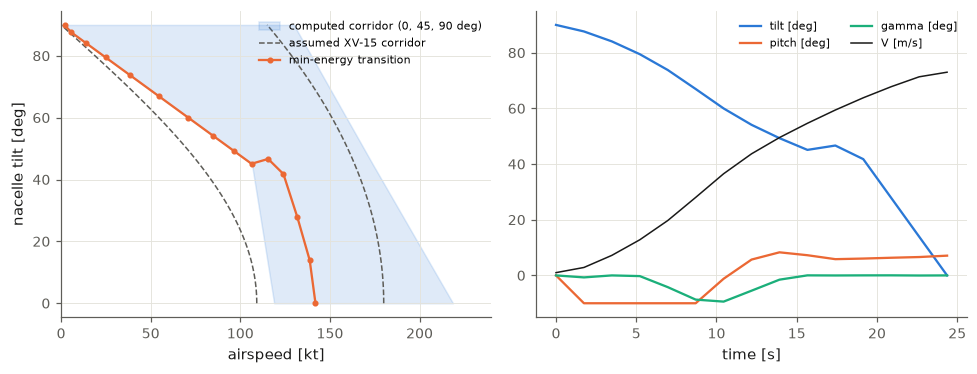

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
grid = onp.linspace(0, 90, 91)
ax1.fill_betweenx(grid, [scalar(case.corridor.velocity_min_m_s(t_)) / u.knot for t_ in grid],
                  [scalar(case.corridor.velocity_max_m_s(t_)) / u.knot for t_ in grid], color=blue, alpha=0.15,
                  label="computed corridor (0, 45, 90 deg)")
ax1.plot([scalar(corridor_assumed.velocity_min_m_s(t_)) / u.knot for t_ in grid], grid, "--", color=ink_muted, lw=1,
         label="assumed XV-15 corridor")
ax1.plot([scalar(corridor_assumed.velocity_max_m_s(t_)) / u.knot for t_ in grid], grid, "--", color=ink_muted, lw=1)
ax1.plot(res.velocity_m_s / u.knot, res.tilt_deg, "o-", color=orange, ms=3, label="min-energy transition")
ax1.set(xlabel="airspeed [kt]", ylabel="nacelle tilt [deg]", xlim=(0, 240))
ax1.legend(fontsize=7, loc="upper right")
ax2.plot(res.time_s, res.tilt_deg, color=blue, label="tilt [deg]")
ax2.plot(res.time_s, res.pitch_deg, color=orange, label="pitch [deg]")
ax2.plot(res.time_s, res.gamma_deg, color=aqua, label="gamma [deg]")
ax2.plot(res.time_s, res.velocity_m_s, color=ink, lw=1, label="V [m/s]")
ax2.set(xlabel="time [s]")
ax2.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

**Reading the solution** (all numbers from the cells above).
- The optimizer **pitches nose-down to the -10 deg attitude limit** in the first seconds and **descends** (gamma down to
  about -9 deg), using the altitude band to trade height for speed. RESULTS.md section 5 reports the same behaviour on
  the 41-node, 7-angle case.
- It **rides the low-speed side** of the computed corridor through the mid nacelle angles, where the wing starts to
  carry weight soonest, then rotates the last nacelle degrees at the **8 deg/s** limit once the wing carries the
  weight.
- The tilt history is not monotonic: at about 15-19 s the nacelles come back up by about 1.5 deg (plot, right). Nothing
  in the problem asks for monotonic conversion; with 15 nodes and a 3-angle corridor this is where the speed reaches
  the kink of the computed low-speed side at 45 deg. A real schedule would add a sign constraint on the rate.
- Through the conversion the rotors sit at their **drive rating** (742 kW per rotor, printed above): that, not the
  machines, caps the power. The machines warm by about 8 to 11 K (motor 60 to 68 C, generator 60 to 71 C, limit
  150 C).
- Cooling is negligible: the machines start at the coolant temperature, so almost no heat reaches the exchanger (fan
  power below 1 W, section 6).

---
## 4. `examples/halo_conversion_corridor.py`

In [34]:
show_source("examples/halo_conversion_corridor.py", 1, 49)

# examples/halo_conversion_corridor.py  lines 1-49
   1  """Computed conversion corridor and trim schedule of the sized Halo reference (plan 039).
   2  
   3  The aircraft is sized first (`solve_halo_sizing()`, the default reference); the corridor flies that numeric
   4  aircraft at take-off mass, sea level, hover rotor speed. Each nacelle angle gets the least and greatest
   5  level-flight trim airspeed inside `CorridorLimits`, with the limit that sets it, and a least-power trim schedule
   6  at the corridor's mid speed.
   7  
   8      python examples/halo_conversion_corridor.py            # writes output/corridor/corridor.png and .json
   9  """
  10  import json
  11  import os
  12  from dataclasses import asdict
  13  
  14  import aerosandbox.tools.units as u
  15  
  16  from aircraft_closure.controls.stability import LongitudinalStability
  17  from aircraft_closure.trajectory.corridor import CorridorLimits, TrimGeometry, solve_corridor, solve_trim
  18  from aircraft_clo

- **L23 placard** = 1.1 x the required maximum speed (210 kt), so 231 kt. Plan 039's limit table says "1.1 x design
  cruise"; the code uses the requirement (the cruise speed was too low a placard: digest section 9.4).
- **L24** seven nacelle angles; **L26** plot labels.
- **L29-49 `halo_corridor_case`** builds the trim inputs from the sized design:
  - the aircraft and the `TiltrotorPointMass` (L32-33);
  - a `StructuralDesignCondition` (L34-40) only to get the mass breakdown and its CG (L41);
  - `TrimGeometry` (L43-45): the CG from the breakdown, the spindle at the wing root quarter chord and wing height,
    and the mast length from the assumptions (1.0 m, plan 031 layout). The sizing constrains the CG to the root
    quarter chord (`halo_sizing.py` L1301, "hover pitch trim"), so x_cg - x_spindle is about zero on the sized
    aircraft (printed in section 2.5);
  - the hover rotor speed throughout (L48): there is no rotor-speed schedule.
  - Default `assumptions=HaloAssumptions()`: the same relaxed-unit issue as in section 3.1.

In [35]:
show_source("examples/halo_conversion_corridor.py", 52, 126)

# examples/halo_conversion_corridor.py  lines 52-126
  52  def run(sizing=None, directory="output/corridor", plot=True):
  53      sizing = sizing if sizing is not None else solve_halo_sizing()
  54      model, geometry, limits, speed_rotor_rad_s = halo_corridor_case(sizing)
  55      stability = LongitudinalStability()
  56      common = dict(mass_kg=sizing.mass_takeoff_kg, altitude_m=0.0, speed_rotor_rad_s=speed_rotor_rad_s)
  57      corridor = solve_corridor(model, stability, geometry, limits, tilts_deg=tilts_deg,
  58                                velocity_max_m_s=1.05 * limits.velocity_placard_m_s, **common)
  59      schedule = []
  60      for low, high in corridor:
  61          if low.trim is None or high.trim is None:
  62              continue
  63          velocity_m_s = 0.5 * (low.velocity_m_s + high.velocity_m_s)
  64          schedule.append(solve_trim(model, stability, geometry, limits, velocity_m_s=velocity_m_s,
  65                                     tilt_deg=low.t

- **L52-65 `run`:** the corridor at the seven angles, search bound 1.05 x placard (so `search_bound` flags a corridor
  that would extend past the placard), then a least-power trim at the mid speed of each angle (the "trim schedule",
  the first controls product for conversion, 039 "Goal").
- **L67-78** the printed table. **L80-87** a JSON record. **L93-122** the plot: filled band, the binding-limit names
  as annotations (`hover` dropped).

---
## 5. `examples/halo_trajectory_computed_corridor.py`

In [36]:
show_source("examples/halo_trajectory_computed_corridor.py")

# examples/halo_trajectory_computed_corridor.py  lines 1-76
   1  """Tier 14 trajectories flown inside the computed conversion corridor (plan 039) instead of the assumed one.
   2  
   3  The aircraft is sized (`solve_halo_sizing()`), its corridor is computed from level-flight trim at sea level
   4  (`examples/halo_conversion_corridor.py`), and the minimum-energy transition and the minimum time to climb are flown
   5  with that corridor as their airspeed limits. The corridor is computed at sea level and the take-off mass; the climb
   6  applies it up to 10,000 ft, an approximation.
   7  
   8  Finding: the minimum-energy transition rides the corridor's low-speed side from about 15 to 100 kt and descends
   9  (flight-path angle down to about -10 deg, inside the +/-30 m altitude band) through 15-90 kt. No level,
  10  constant-acceleration conversion exists inside the computed corridor: with the nacelles high enough for the
  11  corridor, accelerating needs a nose-down attitude bey

- **L1-16 docstring:** the finding of plan 039 for trajectories. The minimum-energy transition rides the low-speed side
  and descends. **No level constant-acceleration conversion exists inside the computed corridor**: with the nacelles
  high enough for the corridor, accelerating needs a nose-down attitude beyond the trajectory model's -10 deg limit,
  and the trajectory model has no disc tilt (the trim that computes the corridor does). So the prescribed transition
  is not flown here.
- **L28-33 `computed_corridor_case`:** the assumed case first (only for its stall speed), then `run_corridor` (the
  full 7-angle corridor, about 14 solves), then the case with `ComputedCorridor`. The corridor is computed at sea level
  and take-off mass; the climb uses it up to 10,000 ft (L5-6: an approximation).
- **L36-45 `run`:** transition and climb, then the plot. **L48-72:** the plot of corridor and paths.

This notebook ran the same chain in miniature: 3 angles in section 2.5, `ComputedCorridor.from_bounds` in 2.6, the
transition in 3.4.

---
## 6. Findings

Checked against the code; each is evidence, not opinion.

1. **The examples rebuild the sized aircraft with the relaxed machine-unit count.** `halo_trajectory_case`
   (`examples/trajectory_optimization.py` L44, `assumptions=HaloAssumptions()`) and `halo_corridor_case`
   (`examples/halo_conversion_corridor.py` L29) default to `HaloAssumptions()`, whose `count_units_motor` and
   `count_units_generator` are `None`. The baseline was solved with whole units fixed. `run()` in `halo_conversion_corridor.py` (L54) and
   `halo_trajectory_computed_corridor.py` (L30-33, L38) and `halo_mission_profile.py` L56 pass only the sizing, so they fly
   machines rated by the relaxed count. The cell below shows the difference in ratings.
2. **`energy_bus_J` and the transition objective include fan power; `power_bus_W` and the docstring do not.** Builder
   L413-414 integrates motor + fan power. `solve_min_energy_transition`'s docstring (`trajectory_optimization.py`
   L192) says "bus (motor electrical) energy", and `TrajectoryResult.power_bus_W` (L133) is motors only, so the
   integral of `power_bus_W` is not `energy_bus_J` in general. In this cold-start transition the fan energy is 0.16
   mWh (below), so it does not matter here; it would with warm machines or in hover, where the fans carry the cooling.
3. **`PowerSupply.power_shaft_generator_W` is the turboshaft-side power** (`tiltrotor.py` L208: generator shaft /
   step-up efficiency). The name says generator. Its uses (L422 against turboshaft available power) are correct.
4. **L421 comment "normalized by the installed motor rating":** `scale_power_W` (L355) is n_rotors x one lane motor's
   rating, half the installed rating with 2 lanes. The flight point multiplies by the lanes
   (`flight_point.py` L385-387). Only a scale; harmless, but the comment is not accurate.
5. **The tilt-rate comment (L374-376)** says a trapezoidal rate variable "only bounds the mean of adjacent node
   rates, which lets them alternate". What section 1.10 demonstrates is different: the interval slope is the mean of
   adjacent node rates, so bounding node rates bounds the slopes too, but it also forbids feasible alternating
   histories (peak node rate 16 deg/s for slopes within 8), and the rate variable has a zig-zag null mode. The
   per-interval form is the right choice; the comment's reason is imprecise.
6. **Trajectory battery path ignores the string protection units.** The Halo topology has 2 `protection_string`
   instances; the flight point puts their resistance in the battery feeder (`flight_point.py` L251-260); the
   trajectory feeds the motors at the battery terminal voltage (L381-383). At 1000 A the drop is about 0.2 V
   (0.15 V rated drop per pole x 2 poles at 703 A, two strings in parallel). Negligible, but an inconsistency.
7. **Plan 039's limit table** gives the placard as "1.1 x design cruise"; the example uses 1.1 x the required maximum
   speed (`halo_conversion_corridor.py` L23, L46).
8. **Wing stall at low speed differs between the two layers.** The trim relaxes stall below 10 m/s
   (`corridor.py` L178); the trajectory applies alpha <= alpha_stall at every node (L433) with the 10 m/s coefficient
   floor. In the solved transition alpha stays far below stall near hover, so it does not bind; it is a modelling
   difference, not an error.

In [37]:
relaxed = build_halo_aircraft(ref.design, r, HaloAssumptions())
instances_r = relaxed.powertrain.topology.instances
for name in ("motor", "generator"):
    sized, relax = model.instance(name), instances_r[name].component
    print(f"{name:<9} units {sized.mass_model.count_units} (sized) vs {scalar(relax.mass_model.count_units):.2f} (default "
          f"assumptions): rating {scalar(sized.power_rated_W)/1e3:.0f} vs {scalar(relax.power_rated_W)/1e3:.0f} kW, "
          f"max torque {scalar(sized.max_torque_Nm):.0f} vs {scalar(relax.max_torque_Nm):.0f} Nm")
check("Finding 1: HaloAssumptions() rebuilds the sized design with different machine ratings",
      abs(scalar(instances_r["motor"].component.power_rated_W) - scalar(motor.power_rated_W)) > 1e3)
e_motor_J = onp.sum(step / 2 * (res.power_bus_W[1:] + res.power_bus_W[:-1]))
e_fan_J = onp.sum(step / 2 * (res.power_fan_W[1:] + res.power_fan_W[:-1]))
print(f"energy_bus_J[-1] {res.energy_bus_J[-1]/3.6e3:.2f} Wh = motors {e_motor_J/3.6e3:.2f} Wh + fans {e_fan_J/3.6e3:.5f} Wh; "
      f"peak fan power {res.power_fan_W.max():.3f} W")
check("Finding 2: the objective energy includes fan energy (motor-only integral differs)",
      abs(res.energy_bus_J[-1] - e_motor_J - e_fan_J) < 1e-3 * res.energy_bus_J[-1] and e_fan_J > 0)

motor     units 2 (sized) vs 2.69 (default assumptions): rating 528 vs 711 kW, max torque 3000 vs 4042 Nm
generator units 3 (sized) vs 4.74 (default assumptions): rating 945 vs 1493 kW, max torque 1410 vs 2228 Nm
PASS  Finding 1: HaloAssumptions() rebuilds the sized design with different machine ratings
energy_bus_J[-1] 10436.65 Wh = motors 10436.65 Wh + fans 0.00016 Wh; peak fan power 0.105 W
PASS  Finding 2: the objective energy includes fan energy (motor-only integral differs)


---
## 7. Gotchas, limits, what's next, review questions

**Gotchas**
- **"Hover" is 1 m/s.** Speed-gamma divides by V. Any problem starting at V = 0 needs a different dynamics class.
- **The final time is a variable inside every constraint.** `time_s` is `linspace(0, t_f, n)`; there is no fixed step.
  Changing `count_nodes` changes resolution, not duration.
- **Derivative constraints are not scaled by AeroSandbox.** The energy defect is in joules; IPOPT's row scaling copes.
  A new state with a huge range should get a sensible variable `scale`.
- **Two corridors, one interface.** Passing a `ComputedCorridor` or a `ConversionCorridor` changes only L417-418.
  The computed one is valid at the mass and altitude it was computed for.
- **The trajectory has no disc tilt; the trim does.** So the trajectory model is stricter than the corridor: a point
  inside the computed corridor is not always flyable by the trajectory model (no level constant-acceleration
  conversion exists).
- **Coefficient floor, true dynamic pressure.** Below 10 m/s the coefficients freeze, forces go as V^2.
- **Pass the sizing's assumptions.** `halo_trajectory_case(sizing)` with defaults flies relaxed machine units
  (Finding 1).

**Limits / what it can't do**
- Axial-only rotor: no H-force, no translational lift, no edgewise profile power, no flapping. The conversion-mode climb
  is "likely flattered" (019).
- Point mass: no pitch dynamics (pitch is algebraic and bounded), no tail loads in the trajectory, no lateral motion.
- Corridor: level flight only (no climbing or accelerating trims), one mass and altitude, hover tip speed throughout,
  CG fixed with nacelle angle, tail outside the rotor wake.
- Battery RC states absent; no return transition; no failure states along trajectories (036 "Deferred").

**What's next** (NEXT_STEPS section 8, decisions 019 and 039 "Deferred"): rotor H-force, an airplane-mode rotor-speed
schedule and disc tilt in the trajectory model (about 2 days); then linearized pitch models from CasADi Jacobians of
`build_trim` at the trim schedule as the plant for control-law design (about 1 day); then lateral-directional trim and
6-DOF with control allocation; rigid-body pitch dynamics (`DynamicsRigidBody2DBody`).

<details><summary>Describe the transcription: states, controls, defects, and how the final time is free.</summary>

States per node: x, h, V, gamma (AeroSandbox speed-gamma), mass, SOC, bus energy, plus one temperature per thermal
machine type (16 n + 1 variables with 3 temperatures). Controls per node: alpha, tilt, thrust and speed per rotor,
battery current, generator torque. The grid is `linspace(0, t_f, n)` with t_f a scalar variable, so the step
h = t_f/(n-1) is symbolic. Each state y gets n - 1 trapezoidal defects y[k+1] - y[k] = h/2 (f[k] + f[k+1]) from
`Opti.constrain_derivative`. Path constraints apply at every node. The builder fixes x, m, SOC, E at t = 0; the caller
adds the rest.
</details>

<details><summary>Why compute the nacelle rate as diff(tilt)/diff(time) instead of a rate variable?</summary>

Tilt is a control, piecewise linear between nodes. The n - 1 interval slopes are exactly its rates, so bounding them
is the exact rate limit with no extra variables. A trapezoidal rate variable r has a zig-zag null mode (r + c(-1)^k
changes no tilt), and its node values must reach 16 deg/s for a history alternating 8 deg/s and hold, so a node bound
of 8 forbids a feasible history.
</details>

<details><summary>Why does the minimum-energy transition descend and pitch nose-down?</summary>

Energy is power times time. Pitching down tilts the thrust forward without extra rotor power, so the aircraft
accelerates sooner, and the altitude band lets it trade potential energy for speed. It rides the low-speed side of
the corridor because the wing starts lifting earlier there. It ends at 1.3 V_stall with the last nacelle degrees at
the 8 deg/s limit, once the wing carries the weight.
</details>

<details><summary>How is the corridor computed, and what sets each side?</summary>

At each nacelle angle, airspeed becomes an Opti variable minimized (low side) or maximized (high side) subject to the
level-flight trim (F_x = 0, F_z = 0, M_y = 0 in thrust, pitch, tail deflection and washed-out disc tilt) and the
limits as margins >= 0. The binding limit is the margin at zero. On the Halo: hover and edgewise mu at 90 deg;
attitude and disc-tilt authority on the low side at mid angles (conservative without H-force); attitude and rotor
power at 0 deg.
</details>

<details><summary>Why is disc tilt multiplied by sin(tau)?</summary>

Washout toward airplane mode (XV-15 practice). Without it the trim could use disc tilt as free thrust vectoring in
airplane mode to cancel moments and lift the low-speed side. At tau = 0 the term vanishes whatever f is (checked at
the 0 deg low bound).
</details>

<details><summary>How do you know the trajectory model agrees with the sizing flight point?</summary>

Identities: hover at V = 0, tilt 90 deg gives n T (1 - f_dl) = W with the hover download exactly (this notebook), and
the trim's hover power equals the point-mass evaluation. The tests show airplane mode with tilt = -alpha reproduces
`build_flight_point` to 1e-9 and a frozen collocated trajectory is within 1.1e-4 (decision 019, "Tests"). The
thermal R and C come from the same `thermal_parameters` as sizing.
</details>

In [38]:
print(f"notebook run time {time.perf_counter() - time_notebook_s:.0f} s")
check_summary()

notebook run time 38 s
32 of 32 checks passed
